# ============================================================
# PHARMALENS AI
# NOTEBOOK 04 — LAUNCH SUCCESS INTELLIGENCE
# ============================================================
#
# Objective:
# Analyze pharmaceutical product launches and determine:
#
# - New product launches
# - Launch cohorts
# - Early launch performance
# - Launch success rate
# - Time-to-peak
# - Launch growth
# - Manufacturer launch performance
# - Therapeutic-class launch performance
# - Launch risk
# - Strategic launch opportunities
#
# Dataset:
# Egyptian Pharmaceutical Market
# Period: 2021–2025
#
# ============================================================

In [3]:
# ============================================================
# 1. IMPORT LIBRARIES
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

import warnings
warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

print("Libraries imported successfully.")

Libraries imported successfully.


In [4]:
import numpy as np

pd.set_option ("display.max_columns" ,None)

In [5]:
# ============================================================
# 1. LOAD CLEANED PROCESSED DATA
# ============================================================

# ------------------------------------------------------------
# File path
# ------------------------------------------------------------

DATA_PATH = "../data/processed/cleaned_pharma_data.parquet"

# ------------------------------------------------------------
# Load data
# ------------------------------------------------------------

df = pd.read_parquet(DATA_PATH)

print("Data loaded successfully.")
print(f"Shape: {df.shape}")

print("\nColumns:")
print(df.columns.tolist())

print("\nFirst 5 rows:")
display(df.head())

Data loaded successfully.
Shape: (909922, 18)

Columns:
['Distribution Channel', 'Therapeutic Class', 'Manufacturer', 'Brand Name', 'Pack Size', 'Product Launch', 'Drug Strength', 'Selling Price', 'Market Category', 'Month', 'Year', 'Sales Units', 'Sales Value', 'Revenue_per_Unit', 'Launch_Year', 'Product_Age_Years', 'New_Product_Flag', 'Month_Number']

First 5 rows:


,Distribution Channel,Therapeutic Class,Manufacturer,Brand Name,Pack Size,Product Launch,Drug Strength,Selling Price,Market Category,Month,Year,Sales Units,Sales Value,Revenue_per_Unit,Launch_Year,Product_Age_Years,New_Product_Flag,Month_Number
0,PHARMACIES,A01A0 STOMATOLOGICALS,ADCO*,HEXITOL,MOUTH WASH 100ML,1990-04-01,000,49.90,KGA ORAL TOPICAL LIQUIDS,2021-01-01,2021,"124,790.00","1,871,850.00",15.00,"1,990.00",31.00,0,1
1,PHARMACIES,A01A0 STOMATOLOGICALS,ADCO*,HEXITOL,MOUTH WASH 100ML,1990-04-01,000,49.90,KGA ORAL TOPICAL LIQUIDS,2021-02-01,2021,"112,962.00","1,694,430.00",15.00,"1,990.00",31.00,0,2
2,PHARMACIES,A01A0 STOMATOLOGICALS,ADCO*,HEXITOL,MOUTH WASH 100ML,1990-04-01,000,49.90,KGA ORAL TOPICAL LIQUIDS,2021-03-01,2021,"108,014.00","1,620,210.00",15.00,"1,990.00",31.00,0,3
3,PHARMACIES,A01A0 STOMATOLOGICALS,ADCO*,HEXITOL,MOUTH WASH 100ML,1990-04-01,000,49.90,KGA ORAL TOPICAL LIQUIDS,2021-04-01,2021,"88,090.00","1,321,350.00",15.00,"1,990.00",31.00,0,4
4,PHARMACIES,A01A0 STOMATOLOGICALS,ADCO*,HEXITOL,MOUTH WASH 100ML,1990-04-01,000,49.90,KGA ORAL TOPICAL LIQUIDS,2021-05-01,2021,"76,111.00","1,141,665.00",15.00,"1,990.00",31.00,0,5


In [4]:
#df=  pd.read_excel ("IMS (2021-2025).xlsx")

In [5]:
#df = df.rename(columns={
    "Sector": "Distribution Channel",
    "ATC4": "Therapeutic Class",
    "Corporation": "Manufacturer",
    "Product": "Brand Name",
    "Pack": "Pack Size",
    "Launch Date": "Product Launch",
    "Strength": "Drug Strength",
    "Retail Price": "Selling Price",
    "NFC3": "Market Category",
    "Period": "Month",
    "Calendar Year": "Year",
    "Units": "Sales Units",
    "LC Value": "Sales Value"
})

In [6]:
# ============================================================
# 3. VALIDATE DATA COLUMNS
# ============================================================

required_columns = [
    "Distribution Channel",
    "Therapeutic Class",
    "Manufacturer",
    "Brand Name",
    "Pack Size",
    "Product Launch",
    "Drug Strength",
    "Selling Price",
    "Market Category",
    "Month",
    "Year",
    "Sales Units",
    "Sales Value"
]

missing_columns = [
    col for col in required_columns
    if col not in df.columns
]

if missing_columns:
    print("Missing columns:")
    print(missing_columns)
else:
    print("All required columns are available.")

print("\nDataset columns:")
print(df.columns.tolist())

All required columns are available.

Dataset columns:
['Distribution Channel', 'Therapeutic Class', 'Manufacturer', 'Brand Name', 'Pack Size', 'Product Launch', 'Drug Strength', 'Selling Price', 'Market Category', 'Month', 'Year', 'Sales Units', 'Sales Value', 'Revenue_per_Unit', 'Launch_Year', 'Product_Age_Years', 'New_Product_Flag', 'Month_Number']


In [7]:
# ============================================================
# 4. DATA TYPE PREPARATION
# ============================================================

df["Product Launch"] = pd.to_datetime(
    df["Product Launch"],
    errors="coerce"
)

df["Month"] = pd.to_datetime(
    df["Month"],
    errors="coerce"
)

df["Year"] = pd.to_numeric(
    df["Year"],
    errors="coerce"
)

df["Sales Units"] = pd.to_numeric(
    df["Sales Units"],
    errors="coerce"
)

df["Sales Value"] = pd.to_numeric(
    df["Sales Value"],
    errors="coerce"
)

df["Selling Price"] = pd.to_numeric(
    df["Selling Price"],
    errors="coerce"
)

print(df.dtypes)

Distribution Channel    string[python]
Therapeutic Class       string[python]
Manufacturer            string[python]
Brand Name              string[python]
Pack Size               string[python]
Product Launch          datetime64[ns]
Drug Strength           string[python]
Selling Price                  float64
Market Category         string[python]
Month                   datetime64[ns]
Year                             int64
Sales Units                    float64
Sales Value                    float64
Revenue_per_Unit               float64
Launch_Year                    float64
Product_Age_Years              float64
New_Product_Flag                 int64
Month_Number                     int32
dtype: object


In [8]:
# ============================================================
# 5. DATA QUALITY CHECK
# ============================================================

quality_check = pd.DataFrame({
    "Column": df.columns,
    "Missing Values": df.isna().sum().values,
    "Missing %": (
        df.isna().mean().values * 100
    ),
    "Unique Values": [
        df[col].nunique()
        for col in df.columns
    ]
})

quality_check.sort_values(
    "Missing %",
    ascending=False
)

,Column,Missing Values,Missing %,Unique Values
15,Product_Age_Years,9335,1.03,53
14,Launch_Year,9335,1.03,49
5,Product Launch,9335,1.03,468
0,Distribution Channel,0,0.00,2
10,Year,0,0.00,5
16,New_Product_Flag,0,0.00,2
13,Revenue_per_Unit,0,0.00,8289
12,Sales Value,0,0.00,408017
11,Sales Units,0,0.00,142846
9,Month,0,0.00,60


In [9]:
# ============================================================
# 6. CREATE PRODUCT IDENTIFIER
# ============================================================

df["Product_ID"] = (
    df["Manufacturer"].astype(str).str.strip()
    + " | "
    + df["Brand Name"].astype(str).str.strip()
    + " | "
    + df["Drug Strength"].astype(str).str.strip()
    + " | "
    + df["Pack Size"].astype(str).str.strip()
)

print("Unique products:", df["Product_ID"].nunique())

Unique products: 16682


In [10]:
# ============================================================
# 7. LAUNCH DATE VALIDATION
# ============================================================

print("Minimum launch date:")
print(df["Product Launch"].min())

print("\nMaximum launch date:")
print(df["Product Launch"].max())

print("\nMissing launch dates:")
print(df["Product Launch"].isna().sum())

Minimum launch date:
1977-07-01 00:00:00

Maximum launch date:
2025-12-01 00:00:00

Missing launch dates:
9335


In [11]:
# ============================================================
# 8. CREATE LAUNCH YEAR
# ============================================================

df["Launch_Year"] = df["Product Launch"].dt.year
df["Launch_Month"] = df["Product Launch"].dt.month
df["Launch_Quarter"] = df["Product Launch"].dt.quarter

df[
    [
        "Product_ID",
        "Product Launch",
        "Launch_Year",
        "Launch_Month",
        "Launch_Quarter"
    ]
].head()

,Product_ID,Product Launch,Launch_Year,Launch_Month,Launch_Quarter
0,ADCO* | HEXITOL | 000 | MOUTH WASH 100ML,1990-04-01,"1,990.00",4.00,2.00
1,ADCO* | HEXITOL | 000 | MOUTH WASH 100ML,1990-04-01,"1,990.00",4.00,2.00
2,ADCO* | HEXITOL | 000 | MOUTH WASH 100ML,1990-04-01,"1,990.00",4.00,2.00
3,ADCO* | HEXITOL | 000 | MOUTH WASH 100ML,1990-04-01,"1,990.00",4.00,2.00
4,ADCO* | HEXITOL | 000 | MOUTH WASH 100ML,1990-04-01,"1,990.00",4.00,2.00


In [12]:
# ============================================================
# 9. FIRST OBSERVED SALES DATE
# ============================================================

first_sales = (
    df.groupby("Product_ID")["Month"]
    .min()
    .reset_index()
    .rename(columns={
        "Month": "First_Sales_Date"
    })
)

df = df.merge(
    first_sales,
    on="Product_ID",
    how="left"
)

df.head()

,Distribution Channel,Therapeutic Class,Manufacturer,Brand Name,Pack Size,Product Launch,Drug Strength,Selling Price,Market Category,Month,Year,Sales Units,Sales Value,Revenue_per_Unit,Launch_Year,Product_Age_Years,New_Product_Flag,Month_Number,Product_ID,Launch_Month,Launch_Quarter,First_Sales_Date
0,PHARMACIES,A01A0 STOMATOLOGICALS,ADCO*,HEXITOL,MOUTH WASH 100ML,1990-04-01,000,49.90,KGA ORAL TOPICAL LIQUIDS,2021-01-01,2021,"124,790.00","1,871,850.00",15.00,"1,990.00",31.00,0,1,ADCO* | HEXITOL | 000 | MOUTH WASH 100ML,4.00,2.00,2021-01-01
1,PHARMACIES,A01A0 STOMATOLOGICALS,ADCO*,HEXITOL,MOUTH WASH 100ML,1990-04-01,000,49.90,KGA ORAL TOPICAL LIQUIDS,2021-02-01,2021,"112,962.00","1,694,430.00",15.00,"1,990.00",31.00,0,2,ADCO* | HEXITOL | 000 | MOUTH WASH 100ML,4.00,2.00,2021-01-01
2,PHARMACIES,A01A0 STOMATOLOGICALS,ADCO*,HEXITOL,MOUTH WASH 100ML,1990-04-01,000,49.90,KGA ORAL TOPICAL LIQUIDS,2021-03-01,2021,"108,014.00","1,620,210.00",15.00,"1,990.00",31.00,0,3,ADCO* | HEXITOL | 000 | MOUTH WASH 100ML,4.00,2.00,2021-01-01
3,PHARMACIES,A01A0 STOMATOLOGICALS,ADCO*,HEXITOL,MOUTH WASH 100ML,1990-04-01,000,49.90,KGA ORAL TOPICAL LIQUIDS,2021-04-01,2021,"88,090.00","1,321,350.00",15.00,"1,990.00",31.00,0,4,ADCO* | HEXITOL | 000 | MOUTH WASH 100ML,4.00,2.00,2021-01-01
4,PHARMACIES,A01A0 STOMATOLOGICALS,ADCO*,HEXITOL,MOUTH WASH 100ML,1990-04-01,000,49.90,KGA ORAL TOPICAL LIQUIDS,2021-05-01,2021,"76,111.00","1,141,665.00",15.00,"1,990.00",31.00,0,5,ADCO* | HEXITOL | 000 | MOUTH WASH 100ML,4.00,2.00,2021-01-01


In [13]:
# ============================================================
# 10. PRODUCT AGE IN MONTHS
# ============================================================

df["Product_Age_Months"] = (
    (
        df["Month"].dt.year
        - df["Product Launch"].dt.year
    ) * 12
    +
    (
        df["Month"].dt.month
        - df["Product Launch"].dt.month
    )
)

df["Product_Age_Months"] = (
    df["Product_Age_Months"]
    .clip(lower=0)
)

df[
    [
        "Product_ID",
        "Product Launch",
        "Month",
        "Product_Age_Months"
    ]
].head()

,Product_ID,Product Launch,Month,Product_Age_Months
0,ADCO* | HEXITOL | 000 | MOUTH WASH 100ML,1990-04-01,2021-01-01,369.00
1,ADCO* | HEXITOL | 000 | MOUTH WASH 100ML,1990-04-01,2021-02-01,370.00
2,ADCO* | HEXITOL | 000 | MOUTH WASH 100ML,1990-04-01,2021-03-01,371.00
3,ADCO* | HEXITOL | 000 | MOUTH WASH 100ML,1990-04-01,2021-04-01,372.00
4,ADCO* | HEXITOL | 000 | MOUTH WASH 100ML,1990-04-01,2021-05-01,373.00


In [14]:
# ============================================================
# 11. NEW PRODUCT IDENTIFICATION
# ============================================================
#
# A product is considered a NEW PRODUCT if:
# Product Launch date exists and falls within the dataset period.
#
# ============================================================

df["Is_New_Product"] = (
    df["Product Launch"].notna()
)

print(
    "Products with valid launch dates:",
    df.loc[
        df["Is_New_Product"],
        "Product_ID"
    ].nunique()
)

Products with valid launch dates: 16500


In [15]:
# ============================================================
# 12. PRODUCT LAUNCH MASTER TABLE
# ============================================================

product_launch = (
    df[df["Is_New_Product"]]
    .groupby("Product_ID")
    .agg(
        Manufacturer=("Manufacturer", "first"),
        Brand_Name=("Brand Name", "first"),
        Therapeutic_Class=("Therapeutic Class", "first"),
        Market_Category=("Market Category", "first"),
        Product_Launch=("Product Launch", "first"),
        Launch_Year=("Launch_Year", "first"),
        Launch_Quarter=("Launch_Quarter", "first"),
        Drug_Strength=("Drug Strength", "first"),
        Pack_Size=("Pack Size", "first"),
        Selling_Price=("Selling Price", "first")
    )
    .reset_index()
)

print("Unique launched products:", len(product_launch))

product_launch.head()

Unique launched products: 16500


,Product_ID,Manufacturer,Brand_Name,Therapeutic_Class,Market_Category,Product_Launch,Launch_Year,Launch_Quarter,Drug_Strength,Pack_Size,Selling_Price
0,15 MAY PHARMACEUTICAL | POWER ACT | 000 | SACH...,15 MAY PHARMACEUTICAL,POWER ACT,A11A4 MVIT + MIN OTHERS,DEP ORAL L ORD UNIT DOSE POWDERS,2015-02-01,"2,015.00",1.00,000,SACHETS 10 15MG,200.00
1,2M WHITES | BEEGU NOSE | 0.900% | NASAL SPRAY ...,2M WHITES,BEEGU NOSE,R01A9 OTH TOPICAL NASAL PREPS,QGC NASAL TOP SPRAYS W/O GAS,2024-11-01,"2,024.00",4.00,0.900%,NASAL SPRAY .9% 100ML,115.00
2,2M WHITES | BEEGU NOSE | 0.900% | NASAL SPRAY ...,2M WHITES,BEEGU NOSE,R01A9 OTH TOPICAL NASAL PREPS,QGC NASAL TOP SPRAYS W/O GAS,2025-01-01,"2,025.00",1.00,0.900%,NASAL SPRAY .9% 30ML,75.00
3,2M WHITES | BEEGU NOSE | 0.900% | NASAL SPRAY ...,2M WHITES,BEEGU NOSE,R01A9 OTH TOPICAL NASAL PREPS,QGC NASAL TOP SPRAYS W/O GAS,2025-01-01,"2,025.00",1.00,0.900%,NASAL SPRAY .9% 70ML,95.00
4,2M WHITES | BEEGU NOSE | 2.300% | NASAL SPRAY ...,2M WHITES,BEEGU NOSE,R01A9 OTH TOPICAL NASAL PREPS,QGC NASAL TOP SPRAYS W/O GAS,2024-10-01,"2,024.00",4.00,2.300%,NASAL SPRAY 2.3% 100ML,115.00


In [16]:
# ============================================================
# 13. LAUNCH COHORT ANALYSIS
# ============================================================

launch_cohort = (
    product_launch
    .groupby("Launch_Year")
    .agg(
        New_Products=("Product_ID", "nunique")
    )
    .reset_index()
)

launch_cohort

,Launch_Year,New_Products
0,"1,977.00",9
1,"1,978.00",16
2,"1,979.00",14
3,"1,980.00",15
4,"1,981.00",21
5,"1,982.00",26
6,"1,983.00",29
7,"1,984.00",12
8,"1,985.00",60
9,"1,986.00",30


In [17]:
# ============================================================
# 13. LAUNCH COHORT ANALYSIS
# ============================================================

launch_cohort = (
    product_launch
    .groupby("Launch_Year")
    .agg(
        New_Products=("Product_ID", "nunique")
    )
    .reset_index()
)

launch_cohort

,Launch_Year,New_Products
0,"1,977.00",9
1,"1,978.00",16
2,"1,979.00",14
3,"1,980.00",15
4,"1,981.00",21
5,"1,982.00",26
6,"1,983.00",29
7,"1,984.00",12
8,"1,985.00",60
9,"1,986.00",30


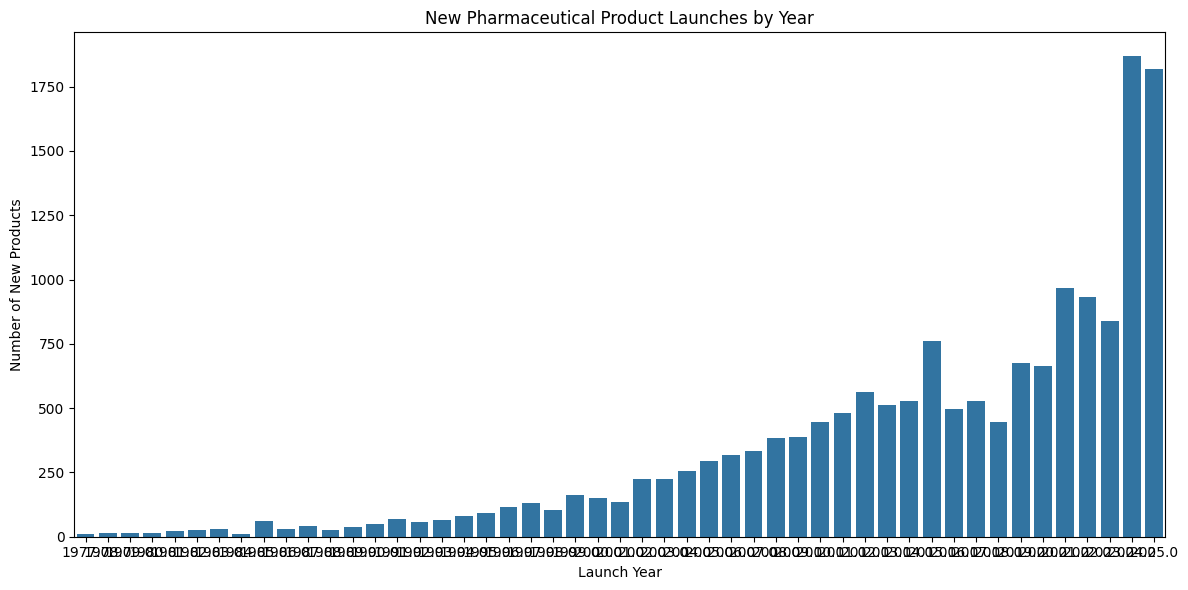

In [18]:
# ============================================================
# 14. NUMBER OF PRODUCT LAUNCHES BY YEAR
# ============================================================

plt.figure(figsize=(12, 6))

sns.barplot(
    data=launch_cohort,
    x="Launch_Year",
    y="New_Products"
)

plt.title("New Pharmaceutical Product Launches by Year")
plt.xlabel("Launch Year")
plt.ylabel("Number of New Products")

plt.tight_layout()
plt.show()

In [19]:
# ============================================================
# 15. LAUNCHES BY THERAPEUTIC CLASS
# ============================================================

launch_by_therapy = (
    product_launch
    .groupby("Therapeutic_Class")
    .agg(
        New_Products=("Product_ID", "nunique")
    )
    .sort_values(
        "New_Products",
        ascending=False
    )
    .reset_index()
)

launch_by_therapy.head(20)

,Therapeutic_Class,New_Products
0,M02A0 TOP A-RHEUMATICS & ANALG,423
1,V03X0 ALL OTH.THERAPEUTIC PRDS,377
2,M01A1 ANTIRHEUMATICS NON-S PLN,352
3,A02B2 PROTON PUMP INHIBITORS,330
4,A12A0 CALCIUM,313
5,M05X0 OTH MUSCULO-SKELETAL PRDS,312
6,R05C0 EXPECTORANTS,308
7,B03A2 IRON COMBINATION PRODUCTS,302
8,D11A0 OTHER DERMATOLOGICAL PREP,277
9,A11C2 VITAMIN D PLAIN,256


In [20]:
# ============================================================
# 16. LAUNCHES BY MANUFACTURER
# ============================================================

launch_by_manufacturer = (
    product_launch
    .groupby("Manufacturer")
    .agg(
        New_Products=("Product_ID", "nunique")
    )
    .sort_values(
        "New_Products",
        ascending=False
    )
    .reset_index()
)

launch_by_manufacturer.head(20)

,Manufacturer,New_Products
0,PHARCO*,541
1,EIPICO/ACDIMA,374
2,GLOBAL NAPI*,356
3,EVA PHARMA*,322
4,HIKMA PLC*,301
5,MARCYRL*,297
6,AMOUN PHARM.CO.*,243
7,HEFNY GROUP*,242
8,MUP/ACDIMA,222
9,MASH*,220


In [21]:
# ============================================================
# 17. LAUNCH PERFORMANCE WINDOW
# ============================================================

# Ensure Product_Age_Months exists
df["Product_Age_Months"] = (
    (
        df["Month"].dt.year
        - df["Product Launch"].dt.year
    ) * 12
    +
    (
        df["Month"].dt.month
        - df["Product Launch"].dt.month
    )
)

df["Product_Age_Months"] = (
    df["Product_Age_Months"].clip(lower=0)
)

def launch_window(age):

    if pd.isna(age):
        return "Unknown"

    elif age <= 2:
        return "First 3 Months"

    elif age <= 5:
        return "Months 4-6"

    elif age <= 11:
        return "Months 7-12"

    else:
        return "12+ Months"


df["Launch_Window"] = df["Product_Age_Months"].apply(
    launch_window
)

print("Launch performance window created.")

Launch performance window created.


In [22]:
# ============================================================
# 18. FIRST 3 MONTHS PERFORMANCE
# ============================================================

first_3_months = (
    df[
        (df["Is_New_Product"]) &
        (df["Product_Age_Months"] <= 2)
    ]
    .groupby("Product_ID")
    .agg(
        First_3M_Units=("Sales Units", "sum"),
        First_3M_Value=("Sales Value", "sum"),
        First_3M_Avg_Price=("Selling Price", "mean")
    )
    .reset_index()
)

# Remove old versions if they already exist
columns_to_remove = [
    "First_3M_Units",
    "First_3M_Value",
    "First_3M_Avg_Price"
]

product_launch = product_launch.drop(
    columns=[
        col for col in columns_to_remove
        if col in product_launch.columns
    ],
    errors="ignore"
)

product_launch = product_launch.merge(
    first_3_months,
    on="Product_ID",
    how="left"
)

print("First 3-month performance added.")

print(
    product_launch[
        [
            "Product_ID",
            "First_3M_Units",
            "First_3M_Value"
        ]
    ].head()
)

First 3-month performance added.
                                          Product_ID  First_3M_Units  \
0  15 MAY PHARMACEUTICAL | POWER ACT | 000 | SACH...             NaN   
1  2M WHITES | BEEGU NOSE | 0.900% | NASAL SPRAY ...          105.00   
2  2M WHITES | BEEGU NOSE | 0.900% | NASAL SPRAY ...          466.00   
3  2M WHITES | BEEGU NOSE | 0.900% | NASAL SPRAY ...           10.00   
4  2M WHITES | BEEGU NOSE | 2.300% | NASAL SPRAY ...             NaN   

   First_3M_Value  
0             NaN  
1        9,975.00  
2       34,950.00  
3          950.00  
4             NaN  


In [23]:
# ============================================================
# 18. FIRST 3 MONTHS PERFORMANCE
# ============================================================

first_3_months = (
    df[
        (df["Is_New_Product"]) &
        (df["Product_Age_Months"] <= 2)
    ]
    .groupby("Product_ID")
    .agg(
        First_3M_Units=("Sales Units", "sum"),
        First_3M_Value=("Sales Value", "sum"),
        First_3M_Avg_Price=("Selling Price", "mean")
    )
    .reset_index()
)

product_launch = product_launch.merge(
    first_3_months,
    on="Product_ID",
    how="left"
)

product_launch.head()

,Product_ID,Manufacturer,Brand_Name,Therapeutic_Class,Market_Category,Product_Launch,Launch_Year,Launch_Quarter,Drug_Strength,Pack_Size,Selling_Price,First_3M_Units_x,First_3M_Value_x,First_3M_Avg_Price_x,First_3M_Units_y,First_3M_Value_y,First_3M_Avg_Price_y
0,15 MAY PHARMACEUTICAL | POWER ACT | 000 | SACH...,15 MAY PHARMACEUTICAL,POWER ACT,A11A4 MVIT + MIN OTHERS,DEP ORAL L ORD UNIT DOSE POWDERS,2015-02-01,"2,015.00",1.00,000,SACHETS 10 15MG,200.00,NaN,NaN,NaN,NaN,NaN,NaN
1,2M WHITES | BEEGU NOSE | 0.900% | NASAL SPRAY ...,2M WHITES,BEEGU NOSE,R01A9 OTH TOPICAL NASAL PREPS,QGC NASAL TOP SPRAYS W/O GAS,2024-11-01,"2,024.00",4.00,0.900%,NASAL SPRAY .9% 100ML,115.00,105.00,"9,975.00",115.00,105.00,"9,975.00",115.00
2,2M WHITES | BEEGU NOSE | 0.900% | NASAL SPRAY ...,2M WHITES,BEEGU NOSE,R01A9 OTH TOPICAL NASAL PREPS,QGC NASAL TOP SPRAYS W/O GAS,2025-01-01,"2,025.00",1.00,0.900%,NASAL SPRAY .9% 30ML,75.00,466.00,"34,950.00",75.00,466.00,"34,950.00",75.00
3,2M WHITES | BEEGU NOSE | 0.900% | NASAL SPRAY ...,2M WHITES,BEEGU NOSE,R01A9 OTH TOPICAL NASAL PREPS,QGC NASAL TOP SPRAYS W/O GAS,2025-01-01,"2,025.00",1.00,0.900%,NASAL SPRAY .9% 70ML,95.00,10.00,950.00,95.00,10.00,950.00,95.00
4,2M WHITES | BEEGU NOSE | 2.300% | NASAL SPRAY ...,2M WHITES,BEEGU NOSE,R01A9 OTH TOPICAL NASAL PREPS,QGC NASAL TOP SPRAYS W/O GAS,2024-10-01,"2,024.00",4.00,2.300%,NASAL SPRAY 2.3% 100ML,115.00,NaN,NaN,NaN,NaN,NaN,NaN


In [38]:
# ============================================================
# 19. FIRST 3 MONTHS PERFORMANCE
# ============================================================

print("Calculating First 3 Months performance...")

first_3_months = (
    df.loc[
        (df["Is_New_Product"]) &
        (df["Product_Age_Months"] <= 2),
        [
            "Product_ID",
            "Sales Units",
            "Sales Value",
            "Selling Price"
        ]
    ]
    .groupby("Product_ID")
    .agg(
        First_3M_Units=("Sales Units", "sum"),
        First_3M_Value=("Sales Value", "sum"),
        First_3M_Avg_Price=("Selling Price", "mean")
    )
    .reset_index()
)

# Remove ALL previous versions
old_columns = [
    col
    for col in product_launch.columns
    if col.startswith("First_3M_")
]

if old_columns:
    product_launch = product_launch.drop(
        columns=old_columns
    )

# Merge
product_launch = product_launch.merge(
    first_3_months,
    on="Product_ID",
    how="left",
    validate="one_to_one"
)

print("✓ First 3 Months added.")

Calculating First 3 Months performance...
✓ First 3 Months added.


In [39]:
# ============================================================
# 20. FIRST 6 MONTHS PERFORMANCE
# ============================================================

print("Calculating First 6 Months performance...")

first_6_months = (
    df.loc[
        (df["Is_New_Product"]) &
        (df["Product_Age_Months"] <= 5),
        [
            "Product_ID",
            "Sales Units",
            "Sales Value"
        ]
    ]
    .groupby("Product_ID")
    .agg(
        First_6M_Units=("Sales Units", "sum"),
        First_6M_Value=("Sales Value", "sum")
    )
    .reset_index()
)

old_columns = [
    col
    for col in product_launch.columns
    if col.startswith("First_6M_")
]

if old_columns:
    product_launch = product_launch.drop(
        columns=old_columns
    )

product_launch = product_launch.merge(
    first_6_months,
    on="Product_ID",
    how="left",
    validate="one_to_one"
)

print("✓ First 6 Months added.")

Calculating First 6 Months performance...
✓ First 6 Months added.


In [25]:
# ============================================================
# 20. FIRST 12 MONTHS PERFORMANCE
# ============================================================

first_12_months = (
    df[
        (df["Is_New_Product"]) &
        (df["Product_Age_Months"] <= 11)
    ]
    .groupby("Product_ID")
    .agg(
        First_12M_Units=("Sales Units", "sum"),
        First_12M_Value=("Sales Value", "sum")
    )
    .reset_index()
)

columns_to_remove = [
    "First_12M_Units",
    "First_12M_Value"
]

product_launch = product_launch.drop(
    columns=[
        col for col in columns_to_remove
        if col in product_launch.columns
    ],
    errors="ignore"
)

product_launch = product_launch.merge(
    first_12_months,
    on="Product_ID",
    how="left"
)

print("First 12-month performance added.")

First 12-month performance added.


In [26]:
# ============================================================
# 21. PEAK PERFORMANCE
# ============================================================

peak_performance = (
    df[
        df["Is_New_Product"]
    ]
    .groupby("Product_ID")
    .agg(
        Peak_Monthly_Units=("Sales Units", "max"),
        Peak_Monthly_Value=("Sales Value", "max")
    )
    .reset_index()
)

columns_to_remove = [
    "Peak_Monthly_Units",
    "Peak_Monthly_Value"
]

product_launch = product_launch.drop(
    columns=[
        col for col in columns_to_remove
        if col in product_launch.columns
    ],
    errors="ignore"
)

product_launch = product_launch.merge(
    peak_performance,
    on="Product_ID",
    how="left"
)

print("Peak performance added.")

Peak performance added.


In [34]:
# ============================================================
# 22. TIME TO PEAK — FINAL MEMORY-SAFE VERSION
# ============================================================

print("Calculating Time to Peak...")

# ------------------------------------------------------------
# 1. Keep only required columns
# ------------------------------------------------------------

peak_data = df.loc[
    df["Is_New_Product"],
    [
        "Product_ID",
        "Product_Age_Months",
        "Sales Value"
    ]
].dropna(
    subset=[
        "Product_ID",
        "Product_Age_Months",
        "Sales Value"
    ]
)

# ------------------------------------------------------------
# 2. Find peak month for each product
# ------------------------------------------------------------

peak_idx = (
    peak_data
    .groupby("Product_ID")["Sales Value"]
    .idxmax()
)

peak_rows = (
    peak_data.loc[
        peak_idx,
        [
            "Product_ID",
            "Product_Age_Months"
        ]
    ]
    .rename(
        columns={
            "Product_Age_Months":
                "Time_to_Peak_Months"
        }
    )
    .reset_index(drop=True)
)

# ------------------------------------------------------------
# 3. IMPORTANT:
# Remove ALL previous Time_to_Peak columns
# ------------------------------------------------------------

time_peak_columns = [
    col
    for col in product_launch.columns
    if col.startswith("Time_to_Peak_Months")
]

if time_peak_columns:

    product_launch = product_launch.drop(
        columns=time_peak_columns
    )

# ------------------------------------------------------------
# 4. Merge cleanly
# ------------------------------------------------------------

product_launch = product_launch.merge(
    peak_rows,
    on="Product_ID",
    how="left",
    validate="one_to_one"
)

# ------------------------------------------------------------
# 5. Final validation
# ------------------------------------------------------------

if "Time_to_Peak_Months" not in product_launch.columns:

    raise RuntimeError(
        "Time_to_Peak_Months was not created successfully."
    )

print("✓ Time-to-Peak calculated successfully.")

print(
    f"✓ Products with Time-to-Peak: "
    f"{product_launch['Time_to_Peak_Months'].notna().sum():,}"
)

print(
    f"✓ Time-to-Peak column count: "
    f"{sum(col == 'Time_to_Peak_Months' for col in product_launch.columns)}"
)

Calculating Time to Peak...
✓ Time-to-Peak calculated successfully.
✓ Products with Time-to-Peak: 16,500
✓ Time-to-Peak column count: 1


In [36]:
# ============================================================
# 23. LAUNCH GROWTH — FINAL MEMORY-SAFE VERSION
# ============================================================

print("Calculating launch growth...")

# ------------------------------------------------------------
# 1. Select only required columns
# ------------------------------------------------------------

growth_data = df.loc[
    df["Is_New_Product"],
    [
        "Product_ID",
        "Product_Age_Months",
        "Sales Value",
        "Sales Units"
    ]
].dropna(
    subset=[
        "Product_ID",
        "Product_Age_Months"
    ]
)

# ------------------------------------------------------------
# 2. Sort only the small required dataset
# ------------------------------------------------------------

growth_data = growth_data.sort_values(
    [
        "Product_ID",
        "Product_Age_Months"
    ]
)

# ------------------------------------------------------------
# 3. Calculate first and latest values
# ------------------------------------------------------------

launch_growth = (
    growth_data
    .groupby("Product_ID")
    .agg(
        First_Month_Value=(
            "Sales Value",
            "first"
        ),
        Latest_Value=(
            "Sales Value",
            "last"
        ),
        First_Month_Units=(
            "Sales Units",
            "first"
        ),
        Latest_Units=(
            "Sales Units",
            "last"
        )
    )
    .reset_index()
)

# ------------------------------------------------------------
# 4. Calculate growth percentages
# ------------------------------------------------------------

launch_growth["Value_Growth_%"] = np.where(

    launch_growth["First_Month_Value"] > 0,

    (
        (
            launch_growth["Latest_Value"]
            /
            launch_growth["First_Month_Value"]
        ) - 1
    ) * 100,

    np.nan
)

launch_growth["Unit_Growth_%"] = np.where(

    launch_growth["First_Month_Units"] > 0,

    (
        (
            launch_growth["Latest_Units"]
            /
            launch_growth["First_Month_Units"]
        ) - 1
    ) * 100,

    np.nan
)

# ------------------------------------------------------------
# 5. Remove ALL previous growth columns
# ------------------------------------------------------------

growth_columns = [
    col
    for col in product_launch.columns
    if col.startswith("Value_Growth_%")
    or col.startswith("Unit_Growth_%")
]

if growth_columns:

    product_launch = product_launch.drop(
        columns=growth_columns
    )

# ------------------------------------------------------------
# 6. Merge cleanly
# ------------------------------------------------------------

product_launch = product_launch.merge(
    launch_growth[
        [
            "Product_ID",
            "Value_Growth_%",
            "Unit_Growth_%"
        ]
    ],
    on="Product_ID",
    how="left",
    validate="one_to_one"
)

# ------------------------------------------------------------
# 7. Validation
# ------------------------------------------------------------

required_growth_columns = [
    "Value_Growth_%",
    "Unit_Growth_%"
]

missing_growth = [
    col
    for col in required_growth_columns
    if col not in product_launch.columns
]

if missing_growth:

    raise RuntimeError(
        f"Growth columns were not created: {missing_growth}"
    )

print("✓ Launch growth calculated successfully.")

print(
    f"✓ Products analyzed: "
    f"{product_launch['Product_ID'].nunique():,}"
)

print(
    f"✓ Value Growth column exists: "
    f"{'Value_Growth_%' in product_launch.columns}"
)

print(
    f"✓ Unit Growth column exists: "
    f"{'Unit_Growth_%' in product_launch.columns}"
)

Calculating launch growth...
✓ Launch growth calculated successfully.
✓ Products analyzed: 16,500
✓ Value Growth column exists: True
✓ Unit Growth column exists: True


In [40]:
# ============================================================
# 24. LAUNCH SUCCESS BENCHMARK
# ============================================================

# ------------------------------------------------------------
# Validate required columns before calculating benchmark
# ------------------------------------------------------------

required_launch_metrics = [
    "First_3M_Value",
    "First_6M_Value",
    "First_12M_Value",
    "Peak_Monthly_Value"
]

missing_metrics = [
    col
    for col in required_launch_metrics
    if col not in product_launch.columns
]

if missing_metrics:

    raise KeyError(
        f"Missing launch performance columns: {missing_metrics}"
    )

# ------------------------------------------------------------
# Calculate benchmark medians
# ------------------------------------------------------------

benchmark = {

    "First_3M_Value_Median":
        product_launch[
            "First_3M_Value"
        ].median(),

    "First_6M_Value_Median":
        product_launch[
            "First_6M_Value"
        ].median(),

    "First_12M_Value_Median":
        product_launch[
            "First_12M_Value"
        ].median(),

    "Peak_Value_Median":
        product_launch[
            "Peak_Monthly_Value"
        ].median()
}

print("Launch Success Benchmarks")
print("=" * 50)

for metric, value in benchmark.items():

    print(
        f"{metric}: {value:,.2f}"
    )

Launch Success Benchmarks
First_3M_Value_Median: 91,432.00
First_6M_Value_Median: 214,776.50
First_12M_Value_Median: 448,488.00
Peak_Value_Median: 200,390.50


In [41]:
# ============================================================
# 25. LAUNCH SUCCESS SCORE
# ============================================================
#
# Success dimensions:
#
# 1. First 3M Value
# 2. First 6M Value
# 3. First 12M Value
# 4. Peak Monthly Value
#
# Each metric is compared against the market launch median.
#
# ============================================================

product_launch["Score_3M"] = (
    product_launch["First_3M_Value"]
    >= benchmark["First_3M_Value_Median"]
).astype(int)

product_launch["Score_6M"] = (
    product_launch["First_6M_Value"]
    >= benchmark["First_6M_Value_Median"]
).astype(int)

product_launch["Score_12M"] = (
    product_launch["First_12M_Value"]
    >= benchmark["First_12M_Value_Median"]
).astype(int)

product_launch["Score_Peak"] = (
    product_launch["Peak_Monthly_Value"]
    >= benchmark["Peak_Value_Median"]
).astype(int)

product_launch["Launch_Success_Score"] = (
    product_launch[
        [
            "Score_3M",
            "Score_6M",
            "Score_12M",
            "Score_Peak"
        ]
    ].sum(axis=1)
)

product_launch.head()

,Product_ID,Manufacturer,Brand_Name,Therapeutic_Class,Market_Category,Product_Launch,Launch_Year,Launch_Quarter,Drug_Strength,Pack_Size,Selling_Price,First_12M_Units,First_12M_Value,Peak_Monthly_Units,Peak_Monthly_Value,Time_to_Peak_Months,Value_Growth_%,Unit_Growth_%,First_3M_Units,First_3M_Value,First_3M_Avg_Price,First_6M_Units,First_6M_Value,Score_3M,Score_6M,Score_12M,Score_Peak,Launch_Success_Score
0,15 MAY PHARMACEUTICAL | POWER ACT | 000 | SACH...,15 MAY PHARMACEUTICAL,POWER ACT,A11A4 MVIT + MIN OTHERS,DEP ORAL L ORD UNIT DOSE POWDERS,2015-02-01,"2,015.00",1.00,000,SACHETS 10 15MG,200.00,NaN,NaN,436.00,"28,340.00",73.00,-94.21,-98.12,NaN,NaN,NaN,NaN,NaN,0,0,0,0,0
1,2M WHITES | BEEGU NOSE | 0.900% | NASAL SPRAY ...,2M WHITES,BEEGU NOSE,R01A9 OTH TOPICAL NASAL PREPS,QGC NASAL TOP SPRAYS W/O GAS,2024-11-01,"2,024.00",4.00,0.900%,NASAL SPRAY .9% 100ML,115.00,932.00,"105,080.00",227.00,"26,105.00",5.00,-82.20,-85.29,105.00,"9,975.00",115.00,868.00,"97,720.00",0,0,0,0,0
2,2M WHITES | BEEGU NOSE | 0.900% | NASAL SPRAY ...,2M WHITES,BEEGU NOSE,R01A9 OTH TOPICAL NASAL PREPS,QGC NASAL TOP SPRAYS W/O GAS,2025-01-01,"2,025.00",1.00,0.900%,NASAL SPRAY .9% 30ML,75.00,671.00,"50,325.00",149.00,"11,175.00",3.00,-68.83,-68.83,466.00,"34,950.00",75.00,671.00,"50,325.00",0,0,0,0,0
3,2M WHITES | BEEGU NOSE | 0.900% | NASAL SPRAY ...,2M WHITES,BEEGU NOSE,R01A9 OTH TOPICAL NASAL PREPS,QGC NASAL TOP SPRAYS W/O GAS,2025-01-01,"2,025.00",1.00,0.900%,NASAL SPRAY .9% 70ML,95.00,10.00,950.00,10.00,950.00,0.00,0.00,0.00,10.00,950.00,95.00,10.00,950.00,0,0,0,0,0
4,2M WHITES | BEEGU NOSE | 2.300% | NASAL SPRAY ...,2M WHITES,BEEGU NOSE,R01A9 OTH TOPICAL NASAL PREPS,QGC NASAL TOP SPRAYS W/O GAS,2024-10-01,"2,024.00",4.00,2.300%,NASAL SPRAY 2.3% 100ML,115.00,989.00,"104,615.00",176.00,"20,240.00",6.00,-62.34,-68.89,NaN,NaN,NaN,652.00,"65,860.00",0,0,0,0,0


In [42]:
# ============================================================
# 26. LAUNCH SUCCESS CLASSIFICATION
# ============================================================

def classify_launch(score):

    if score == 4:
        return "Highly Successful"

    elif score == 3:
        return "Successful"

    elif score == 2:
        return "Moderate"

    elif score == 1:
        return "Weak"

    else:
        return "Unsuccessful"


product_launch["Launch_Success_Category"] = (
    product_launch["Launch_Success_Score"]
    .apply(classify_launch)
)

product_launch[
    [
        "Product_ID",
        "Launch_Success_Score",
        "Launch_Success_Category"
    ]
].head(20)

,Product_ID,Launch_Success_Score,Launch_Success_Category
0,15 MAY PHARMACEUTICAL | POWER ACT | 000 | SACH...,0,Unsuccessful
1,2M WHITES | BEEGU NOSE | 0.900% | NASAL SPRAY ...,0,Unsuccessful
2,2M WHITES | BEEGU NOSE | 0.900% | NASAL SPRAY ...,0,Unsuccessful
3,2M WHITES | BEEGU NOSE | 0.900% | NASAL SPRAY ...,0,Unsuccessful
4,2M WHITES | BEEGU NOSE | 2.300% | NASAL SPRAY ...,0,Unsuccessful
5,2M WHITES | DK WHITE D3+K2 | 000 | HA GEL CAPS 60,1,Weak
6,2M WHITES | MAG WHITES | 000 | TABS 30,0,Unsuccessful
7,2M WHITES | MAG WHITES | 000 | TABS 60,3,Successful
8,2M WHITES | MELATOWHITE | 5MG | TABS 5MG 30,0,Unsuccessful
9,2M WHITES | NEURAWHITE | 000 | SUBLING.TABS 30,0,Unsuccessful


In [43]:
# ============================================================
# 27. OVERALL LAUNCH SUCCESS RATE
# ============================================================

success_rate = (
    product_launch[
        "Launch_Success_Category"
    ]
    .isin([
        "Highly Successful",
        "Successful"
    ])
    .mean()
    * 100
)

print(
    f"Overall Launch Success Rate: {success_rate:.2f}%"
)

Overall Launch Success Rate: 18.24%


In [44]:
# ============================================================
# 28. LAUNCH SUCCESS DISTRIBUTION
# ============================================================

success_distribution = (
    product_launch[
        "Launch_Success_Category"
    ]
    .value_counts()
    .reset_index()
)

success_distribution.columns = [
    "Launch_Success_Category",
    "Number_of_Products"
]

success_distribution

,Launch_Success_Category,Number_of_Products
0,Unsuccessful,7479
1,Weak,5505
2,Highly Successful,2409
3,Successful,600
4,Moderate,507


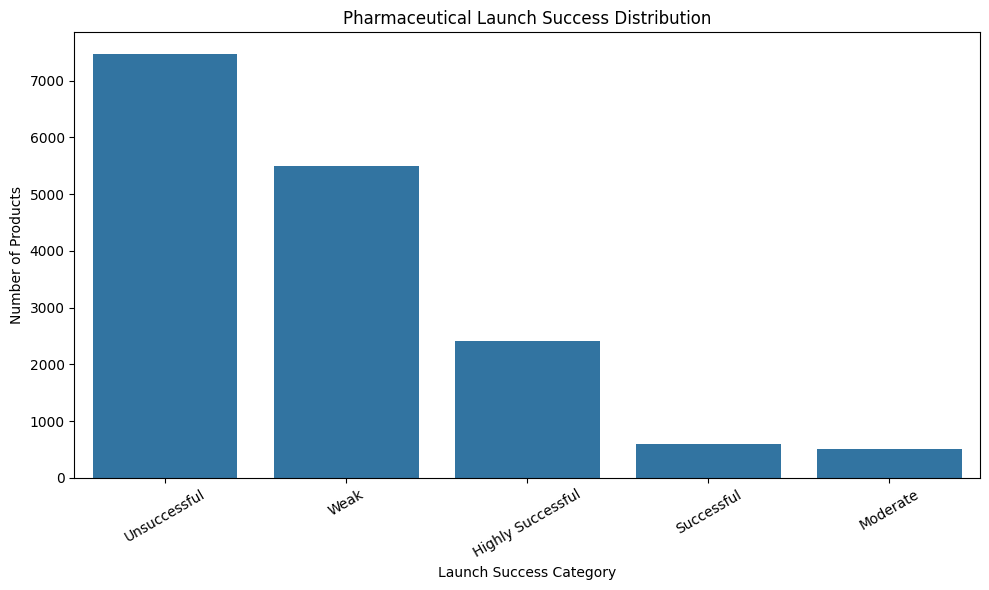

In [45]:
# ============================================================
# 29. SUCCESS CATEGORY VISUALIZATION
# ============================================================

plt.figure(figsize=(10, 6))

sns.barplot(
    data=success_distribution,
    x="Launch_Success_Category",
    y="Number_of_Products"
)

plt.title("Pharmaceutical Launch Success Distribution")
plt.xlabel("Launch Success Category")
plt.ylabel("Number of Products")

plt.xticks(rotation=30)

plt.tight_layout()
plt.show()

In [46]:
# ============================================================
# 30. LAUNCH SUCCESS BY YEAR
# ============================================================

success_by_year = (
    product_launch
    .groupby("Launch_Year")
    .agg(
        New_Products=("Product_ID", "nunique"),
        Successful_Launches=(
            "Launch_Success_Category",
            lambda x:
                x.isin([
                    "Highly Successful",
                    "Successful"
                ]).sum()
        )
    )
    .reset_index()
)

success_by_year["Success_Rate_%"] = (
    success_by_year["Successful_Launches"]
    /
    success_by_year["New_Products"]
    * 100
)

success_by_year

,Launch_Year,New_Products,Successful_Launches,Success_Rate_%
0,"1,977.00",9,0,0.00
1,"1,978.00",16,0,0.00
2,"1,979.00",14,0,0.00
3,"1,980.00",15,0,0.00
4,"1,981.00",21,0,0.00
5,"1,982.00",26,0,0.00
6,"1,983.00",29,0,0.00
7,"1,984.00",12,0,0.00
8,"1,985.00",60,0,0.00
9,"1,986.00",30,0,0.00


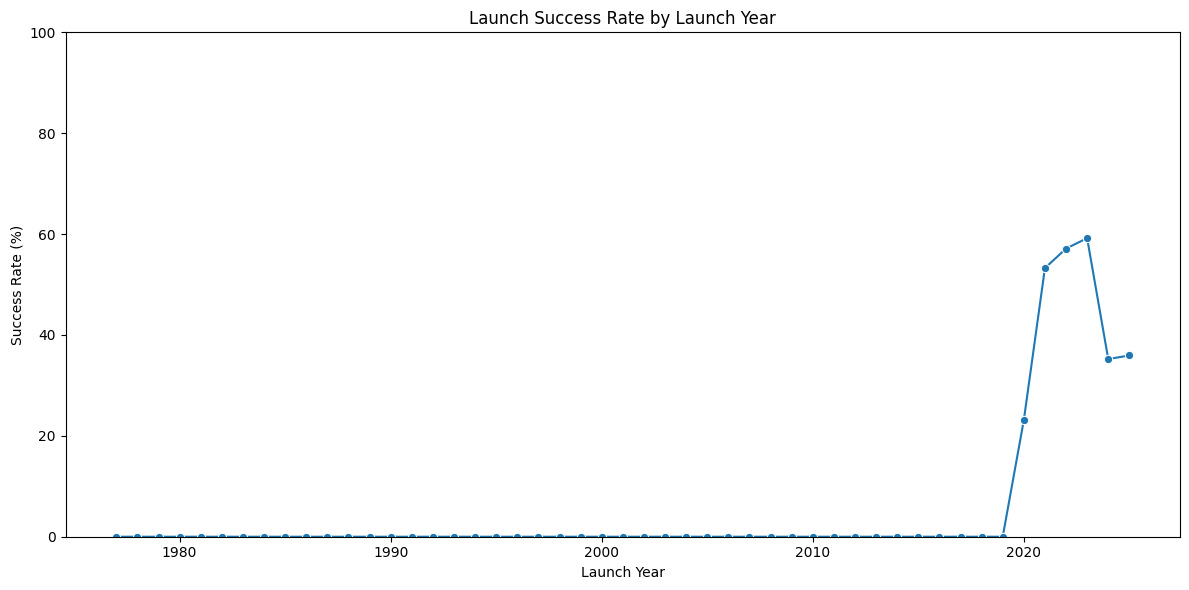

In [47]:
# ============================================================
# 31. SUCCESS RATE TREND
# ============================================================

plt.figure(figsize=(12, 6))

sns.lineplot(
    data=success_by_year,
    x="Launch_Year",
    y="Success_Rate_%",
    marker="o"
)

plt.title("Launch Success Rate by Launch Year")
plt.xlabel("Launch Year")
plt.ylabel("Success Rate (%)")

plt.ylim(0, 100)

plt.tight_layout()
plt.show()

In [48]:
# ============================================================
# 32. MANUFACTURER LAUNCH SUCCESS
# ============================================================

manufacturer_launch_success = (
    product_launch
    .groupby("Manufacturer")
    .agg(
        New_Products=("Product_ID", "nunique"),

        Successful_Launches=(
            "Launch_Success_Category",
            lambda x:
                x.isin([
                    "Highly Successful",
                    "Successful"
                ]).sum()
        ),

        Avg_Success_Score=(
            "Launch_Success_Score",
            "mean"
        ),

        Avg_First_12M_Value=(
            "First_12M_Value",
            "mean"
        )
    )
    .reset_index()
)

manufacturer_launch_success[
    "Success_Rate_%"
] = (
    manufacturer_launch_success[
        "Successful_Launches"
    ]
    /
    manufacturer_launch_success[
        "New_Products"
    ]
    * 100
)

manufacturer_launch_success = (
    manufacturer_launch_success
    .sort_values(
        [
            "Success_Rate_%",
            "New_Products"
        ],
        ascending=False
    )
)

manufacturer_launch_success.head(20)

,Manufacturer,New_Products,Successful_Launches,Avg_Success_Score,Avg_First_12M_Value,Success_Rate_%
1338,VIOMIX*,9,9,3.67,"4,997,963.44",100.00
747,MAJESTIC BIOPHARMA*,8,8,4.00,"5,368,502.85",100.00
142,ATLAS PHARMA*,6,6,3.50,"2,057,115.00",100.00
883,NIG NUTRITIONS*,5,5,4.00,"3,680,769.00",100.00
1209,SOLOVIT*,5,5,4.00,"19,748,486.58",100.00
292,CORVIT PHARMA*,4,4,4.00,"15,316,966.08",100.00
477,GENERAL MEDICAL GR.*,4,4,4.00,"25,691,647.50",100.00
1226,STEMYA PHARMA*,4,4,4.00,"3,244,241.99",100.00
1277,TRB CHEMEDICA AG*,4,4,4.00,"2,530,021.04",100.00
285,CONTENT GROUP*,3,3,4.00,"7,230,523.33",100.00


In [49]:
# ============================================================
# 33. RELIABLE MANUFACTURER BENCHMARK
# ============================================================

manufacturer_reliable = (
    manufacturer_launch_success[
        manufacturer_launch_success["New_Products"] >= 5
    ]
    .copy()
)

manufacturer_reliable.head(20)

,Manufacturer,New_Products,Successful_Launches,Avg_Success_Score,Avg_First_12M_Value,Success_Rate_%
1338,VIOMIX*,9,9,3.67,"4,997,963.44",100.00
747,MAJESTIC BIOPHARMA*,8,8,4.00,"5,368,502.85",100.00
142,ATLAS PHARMA*,6,6,3.50,"2,057,115.00",100.00
883,NIG NUTRITIONS*,5,5,4.00,"3,680,769.00",100.00
1209,SOLOVIT*,5,5,4.00,"19,748,486.58",100.00
906,NOW*,45,42,3.78,"5,115,767.73",93.33
716,LIMITLESS NATURALS,70,64,3.76,"20,848,349.83",91.43
1370,XEEDIA PHARMA*,19,17,3.58,"13,592,609.57",89.47
723,LIPTIS NUTRITION,22,19,3.45,"11,590,376.03",86.36
67,ALFA VITAMINS LAB,6,5,3.33,"1,024,987.50",83.33


In [50]:
# ============================================================
# 34. THERAPEUTIC CLASS LAUNCH SUCCESS
# ============================================================

therapy_launch_success = (
    product_launch
    .groupby("Therapeutic_Class")
    .agg(
        New_Products=("Product_ID", "nunique"),

        Successful_Launches=(
            "Launch_Success_Category",
            lambda x:
                x.isin([
                    "Highly Successful",
                    "Successful"
                ]).sum()
        ),

        Avg_Success_Score=(
            "Launch_Success_Score",
            "mean"
        ),

        Avg_First_12M_Value=(
            "First_12M_Value",
            "mean"
        )
    )
    .reset_index()
)

therapy_launch_success[
    "Success_Rate_%"
] = (
    therapy_launch_success[
        "Successful_Launches"
    ]
    /
    therapy_launch_success[
        "New_Products"
    ]
    * 100
)

therapy_launch_success = (
    therapy_launch_success
    .sort_values(
        "Success_Rate_%",
        ascending=False
    )
)

therapy_launch_success.head(20)

,Therapeutic_Class,New_Products,Successful_Launches,Avg_Success_Score,Avg_First_12M_Value,Success_Rate_%
123,B03D0 HIF-PH INHIBITORS,3,3,3.67,"2,013,483.33",100.00
125,B06D0 HEREDITAR ANGIOEDEMA PRD,2,2,4.00,"599,680.00",100.00
67,A10P5 SGLT2 INH&DPP-IV INH COM,17,17,3.94,"12,761,683.45",100.00
208,G03A3 BIPHASIC PREPARATIONS,1,1,3.00,"6,172,126.00",100.00
53,A10C9 OTH H INSULINS+ANALOGUES,3,3,3.33,"12,701,130.00",100.00
435,"R03D2 CORTICOIDS, SYSTEMIC",1,1,4.00,"1,864,185.00",100.00
36,A06B1 OSMOTIC BOWEL CLEANSERS,1,1,4.00,"1,272,887.00",100.00
132,C01F0 POSITIVE INOTROPIC AGENTS,2,2,3.50,"449,610.00",100.00
298,J07E7 RSV VACCINES,1,1,4.00,"549,000.00",100.00
154,C07B2 COMB + OTHER DRUG GROUP C,4,4,4.00,"2,403,264.98",100.00


In [51]:
# ============================================================
# 35. MARKET CATEGORY LAUNCH PERFORMANCE
# ============================================================

category_launch_success = (
    product_launch
    .groupby("Market_Category")
    .agg(
        New_Products=("Product_ID", "nunique"),

        Successful_Launches=(
            "Launch_Success_Category",
            lambda x:
                x.isin([
                    "Highly Successful",
                    "Successful"
                ]).sum()
        ),

        Avg_First_12M_Value=(
            "First_12M_Value",
            "mean"
        )
    )
    .reset_index()
)

category_launch_success[
    "Success_Rate_%"
] = (
    category_launch_success["Successful_Launches"]
    /
    category_launch_success["New_Products"]
    * 100
)

category_launch_success

,Market_Category,New_Products,Successful_Launches,Avg_First_12M_Value,Success_Rate_%
0,AAA ORAL S ORD TABLETS,2039,227,"8,730,311.83",11.13
1,AAB ORAL DISINTEGRATING TABS,90,34,"6,114,439.00",37.78
2,AAE ORAL S ORD BUCCAL TABS,1,0,NaN,0.00
3,AAF ORAL S ORD SUBLINGUAL TABS,55,10,"1,262,245.05",18.18
4,AAG ORAL S ORD CHEWABLE TABS,169,29,"1,802,109.59",17.16
...,...,...,...,...,...
203,TYR VAGINAL INTRA-UTERINE DEVICES,4,0,NaN,0.00
204,VAH NON-HUMAN USE EFFERV TABS,1,0,NaN,0.00
205,VMA NON-HUMAN USE AMPOULES,1,0,NaN,0.00
206,VPA NON-HUMAN USE VIALS,3,0,NaN,0.00


In [52]:
# ============================================================
# 36. LAUNCH PERFORMANCE BY DISTRIBUTION CHANNEL
# ============================================================

channel_launch = (
    df[df["Is_New_Product"]]
    .groupby("Distribution Channel")
    .agg(
        Sales_Value=("Sales Value", "sum"),
        Sales_Units=("Sales Units", "sum"),
        Products=("Product_ID", "nunique")
    )
    .reset_index()
    .sort_values(
        "Sales_Value",
        ascending=False
    )
)

channel_launch

,Distribution Channel,Sales_Value,Sales_Units,Products
0,PHARMACIES,"610,305,693,087.42","10,174,870,462.33",16416
1,STORES,"264,642,268,752.45","4,818,598,919.91",12922


In [53]:
# ============================================================ # 37. TOP SUCCESSFUL LAUNCHES # ============================================================ 
# ------------------------------------------------------------ # Check required columns # ------------------------------------------------------------ 
required_columns = [ "Product_ID", "Manufacturer", "Brand_Name", "Therapeutic_Class", "Launch_Year", "First_3M_Value", "First_6M_Value", "First_12M_Value", "Peak_Monthly_Value", "Launch_Success_Score", "Launch_Success_Category" ] 

missing_columns = [ col for col in required_columns if col not in product_launch.columns ] 
if missing_columns: raise KeyError( f"Missing columns in product_launch: {missing_columns}" ) 
    
# ------------------------------------------------------------ # Time-to-Peak is optional for displaying the table # ------------------------------------------------------------ 
display_columns = [ "Product_ID", "Manufacturer", "Brand_Name", "Therapeutic_Class", "Launch_Year", "First_3M_Value", "First_6M_Value", "First_12M_Value", "Peak_Monthly_Value" ] 
if "Time_to_Peak_Months" in product_launch.columns: 
    display_columns.append( "Time_to_Peak_Months" ) 
    display_columns.extend([ "Launch_Success_Score", "Launch_Success_Category" ]) 
# ------------------------------------------------------------ 
# Create Top Successful Launches
# ------------------------------------------------------------ 
top_successful_launches = ( product_launch .sort_values( [ "Launch_Success_Score", "First_12M_Value" ], ascending=False ) [display_columns] .head(50) ) 
print( "Top successful launches:" ) 
top_successful_launches 
# ============================================================ # CHECK TIME-TO-PEAK COLUMN # ============================================================ 
print( "Time_to_Peak_Months exists:", "Time_to_Peak_Months" in product_launch.columns ) 
print( "\nProduct Launch columns:" ) 
print( product_launch.columns.tolist() )

top_successful_launches

Top successful launches:
Time_to_Peak_Months exists: True

Product Launch columns:
['Product_ID', 'Manufacturer', 'Brand_Name', 'Therapeutic_Class', 'Market_Category', 'Product_Launch', 'Launch_Year', 'Launch_Quarter', 'Drug_Strength', 'Pack_Size', 'Selling_Price', 'First_12M_Units', 'First_12M_Value', 'Peak_Monthly_Units', 'Peak_Monthly_Value', 'Time_to_Peak_Months', 'Value_Growth_%', 'Unit_Growth_%', 'First_3M_Units', 'First_3M_Value', 'First_3M_Avg_Price', 'First_6M_Units', 'First_6M_Value', 'Score_3M', 'Score_6M', 'Score_12M', 'Score_Peak', 'Launch_Success_Score', 'Launch_Success_Category']


,Product_ID,Manufacturer,Brand_Name,Therapeutic_Class,Launch_Year,First_3M_Value,First_6M_Value,First_12M_Value,Peak_Monthly_Value,Time_to_Peak_Months,Launch_Success_Score,Launch_Success_Category
6317,HALEON* | PANADOL | 500MG | TABS ADVANCE 500MG 48,HALEON*,PANADOL,N02B0 NON-NARCOTIC ANALGESICS,"2,023.00","124,906,316.00","268,880,856.00","564,494,554.00","118,005,824.00",12.00,4,Highly Successful
2557,BIOMED PHARMA.* | BIOLEGAM | 60MG | F.C.T.100M...,BIOMED PHARMA.*,BIOLEGAM,G04E1 ERECT DYS PRD PDE5 INHIB,"2,024.00","56,826,624.00","170,116,608.00","518,548,608.00","181,237,056.00",12.00,4,Highly Successful
4609,ELI LILLY* | MOUNJARO | 000 | KPP 15/0.6 2.4ML,ELI LILLY*,MOUNJARO,A10S0 GLP-1 AGONIST A-DIABS,"2,025.00","191,754,750.00","514,008,000.00","514,008,000.00","135,217,500.00",4.00,4,Highly Successful
6308,HALEON* | PANADOL AC HEAD CO | 2MG | FCT 500/3...,HALEON*,PANADOL AC HEAD CO,R05A0 COLD PREPARATIONS,"2,024.00","70,295,199.00","155,773,605.00","454,387,427.00","96,466,978.00",9.00,4,Highly Successful
2593,BIOMED PHARMA.* | GABIMASH | 800MG | TABS 800M...,BIOMED PHARMA.*,GABIMASH,N02D0 GABAPENTINOID PRODUCTS,"2,022.00","35,111,959.44","141,292,269.87","398,226,075.87","267,912,144.00",32.00,4,Highly Successful
7363,HORUS* | VIRECTA | 100MG | FILM C.TABS 100MG 12,HORUS*,VIRECTA,G04E1 ERECT DYS PRD PDE5 INHIB,"2,023.00","96,548,512.50","184,362,343.50","394,362,745.50","72,507,468.00",25.00,4,Highly Successful
1790,ASTRAZENECA* | CRESTOR | 20MG | FILM C.TABS 20...,ASTRAZENECA*,CRESTOR,C10A1 STATINS (HMG-COA RED),"2,023.00","44,521,750.00","150,596,570.00","381,561,590.00","43,955,400.00",11.00,4,Highly Successful
14269,SANDOZ* | FORADIL | 12Y | CAPS INHALER 12Y 60,SANDOZ*,FORADIL,R03A3 LONG-ACT B2-AGON INHAL,"2,024.00","147,600,320.00","243,829,040.00","356,919,360.00","66,697,680.00",1.00,4,Highly Successful
10908,NILE* | UROSOLVINE-N | 0.140MG | EFF GRN 0.5/ ...,NILE*,UROSOLVINE-N,M04A0 ANTI-GOUT PREPARATIONS,"2,025.00","118,655,874.00","291,678,538.00","356,911,605.46","79,536,356.00",4.00,4,Highly Successful
14249,SANDOZ* | DICLAC | 75MG | PRO.R.TAB.ID 75MG 30,SANDOZ*,DICLAC,M01A1 ANTIRHEUMATICS NON-S PLN,"2,024.00","54,116,235.00","121,638,510.00","328,270,050.00","48,492,405.00",16.00,4,Highly Successful


In [54]:
# ============================================================
# 38. WEAK / UNSUCCESSFUL LAUNCHES
# ============================================================

weak_launches = (
    product_launch[
        product_launch[
            "Launch_Success_Category"
        ].isin([
            "Weak",
            "Unsuccessful"
        ])
    ]
    .sort_values(
        "First_12M_Value",
        ascending=True
    )
)

weak_launches.head(50)

,Product_ID,Manufacturer,Brand_Name,Therapeutic_Class,Market_Category,Product_Launch,Launch_Year,Launch_Quarter,Drug_Strength,Pack_Size,Selling_Price,First_12M_Units,First_12M_Value,Peak_Monthly_Units,Peak_Monthly_Value,Time_to_Peak_Months,Value_Growth_%,Unit_Growth_%,First_3M_Units,First_3M_Value,First_3M_Avg_Price,First_6M_Units,First_6M_Value,Score_3M,Score_6M,Score_12M,Score_Peak,Launch_Success_Score,Launch_Success_Category
10943,NOVARTIS | AFINITOR | 10MG | TABS SUBS 10MG 10,NOVARTIS,AFINITOR,L01H9 PKI A-NEOPLASTIC OTHER,AAA ORAL S ORD TABLETS,2021-11-01,"2,021.00",4.00,10MG,TABS SUBS 10MG 10,0.01,3.00,0.03,3.00,0.03,4.00,0.00,0.00,NaN,NaN,NaN,3.00,0.03,0,0,0,0,0,Unsuccessful
2075,AUG PHARMA* | SANSO BABY WATER | 000 | SYRUP 50ML,AUG PHARMA*,SANSO BABY WATER,A02A4 ANTACIDS + ANTIFLATULENTS,DGM ORAL L ORD SYRUPS,2020-03-01,"2,020.00",1.00,000,SYRUP 50ML,7.50,1.00,7.50,1.00,7.50,10.00,0.00,0.00,NaN,NaN,NaN,NaN,NaN,0,0,0,0,0,Unsuccessful
942,ALEXANDRIA* | FUROSEMIDE | 40MG | TABS 40MG 1000,ALEXANDRIA*,FUROSEMIDE,C03A2 LOOP DIURETICS PLAIN,AAA ORAL S ORD TABLETS,2023-10-01,"2,023.00",4.00,40MG,TABS 40MG 1000,210.00,0.06,15.24,0.03,8.94,6.00,-29.53,0.00,NaN,NaN,NaN,NaN,NaN,0,0,0,0,0,Unsuccessful
3621,DELTA GRAND PH* | DEXAMETHA SOD PHOS | 8MG | S...,DELTA GRAND PH*,DEXAMETHA SOD PHOS,H02A1 INJ CORTICOSTEROIDS PLAIN,FMA PARENTERAL ORDINARY AMPOULES,2024-03-01,"2,024.00",1.00,8MG,SIS IV/IM/IA 8MG 2ML,2.88,6.00,17.28,6.00,17.28,1.00,0.00,0.00,6.00,17.28,2.88,6.00,17.28,0,0,0,0,0,Unsuccessful
1916,ATCO* | GRALIPENTIN XR | 300MG | FILM C.TABS 3...,ATCO*,GRALIPENTIN XR,N02D0 GABAPENTINOID PRODUCTS,ABC ORAL S ORD FILM-COATED TABS,2021-03-01,"2,021.00",1.00,300MG,FILM C.TABS 300MG 10,20.00,1.00,20.00,1.00,20.00,0.00,0.00,0.00,1.00,20.00,20.00,1.00,20.00,0,0,0,0,0,Unsuccessful
8023,KAHIRA* | DESLARGYL | 5MG | F.C.TABS 5MG 5,KAHIRA*,DESLARGYL,R06A0 ANTIHISTAMINES SYSTEMIC,ABC ORAL S ORD FILM-COATED TABS,2022-10-01,"2,022.00",4.00,5MG,F.C.TABS 5MG 5,10.00,2.00,20.00,2.00,20.00,10.00,-50.00,-50.00,NaN,NaN,NaN,NaN,NaN,0,0,0,0,0,Unsuccessful
5220,FIPCO* | RINGER ACETATE | 000 | INFUS.BOT 500ML,FIPCO*,RINGER ACETATE,K01A9 OTHER ELECTROLYTE SOLNS,FQC PARENT ORD INF VIALS/BOTTLES,2020-03-01,"2,020.00",1.00,000,INFUS.BOT 500ML,10.50,2.00,21.00,9.00,94.50,27.00,350.00,350.00,NaN,NaN,NaN,NaN,NaN,0,0,0,0,0,Unsuccessful
14022,ROVENTIS PHARMA | ORISOLE | 000 | MOUTH SOLUT....,ROVENTIS PHARMA,ORISOLE,A01A0 STOMATOLOGICALS,KGA ORAL TOPICAL LIQUIDS,2021-07-01,"2,021.00",3.00,000,MOUTH SOLUT. 60ML,25.00,1.00,25.00,1.00,25.00,0.00,0.00,0.00,1.00,25.00,25.00,1.00,25.00,0,0,0,0,0,Unsuccessful
10745,NEWPORT* | ISOPRINOSINE | 500MG | TABS 500MG 20,NEWPORT*,ISOPRINOSINE,J05B9 ANTIVIRALS OTHERS,AAA ORAL S ORD TABLETS,2022-05-01,"2,022.00",2.00,500MG,TABS 500MG 20,13.85,2.00,27.70,2.00,27.70,0.00,0.00,0.00,2.00,27.70,13.85,2.00,27.70,0,0,0,0,0,Unsuccessful
15629,UNI PHARMA* | CITALIFE | 10MG | FILM C.TABS 10...,UNI PHARMA*,CITALIFE,N06A4 SSRI ANTIDEPRESSANTS,ABC ORAL S ORD FILM-COATED TABS,2022-06-01,"2,022.00",2.00,10MG,FILM C.TABS 10MG 20,31.20,1.00,31.20,1.00,31.20,0.00,0.00,0.00,1.00,31.20,31.20,1.00,31.20,0,0,0,0,0,Unsuccessful


In [55]:
# ============================================================
# 39. LAUNCH RISK SCORE
# ============================================================
#
# Higher score = higher launch risk.
#
# Risk factors:
#
# 1. Weak first 3-month performance
# 2. Weak first 6-month performance
# 3. Slow time-to-peak
# 4. Negative growth
#
# ============================================================

product_launch["Risk_3M"] = (
    product_launch["First_3M_Value"]
    < benchmark["First_3M_Value_Median"]
).astype(int)

product_launch["Risk_6M"] = (
    product_launch["First_6M_Value"]
    < benchmark["First_6M_Value_Median"]
).astype(int)

product_launch["Risk_Peak"] = (
    product_launch["Time_to_Peak_Months"]
    > product_launch["Time_to_Peak_Months"].median()
).astype(int)

product_launch["Risk_Growth"] = (
    product_launch["Value_Growth_%"] < 0
).astype(int)

product_launch["Launch_Risk_Score"] = (
    product_launch[
        [
            "Risk_3M",
            "Risk_6M",
            "Risk_Peak",
            "Risk_Growth"
        ]
    ].sum(axis=1)
)

product_launch.head()

,Product_ID,Manufacturer,Brand_Name,Therapeutic_Class,Market_Category,Product_Launch,Launch_Year,Launch_Quarter,Drug_Strength,Pack_Size,Selling_Price,First_12M_Units,First_12M_Value,Peak_Monthly_Units,Peak_Monthly_Value,Time_to_Peak_Months,Value_Growth_%,Unit_Growth_%,First_3M_Units,First_3M_Value,First_3M_Avg_Price,First_6M_Units,First_6M_Value,Score_3M,Score_6M,Score_12M,Score_Peak,Launch_Success_Score,Launch_Success_Category,Risk_3M,Risk_6M,Risk_Peak,Risk_Growth,Launch_Risk_Score
0,15 MAY PHARMACEUTICAL | POWER ACT | 000 | SACH...,15 MAY PHARMACEUTICAL,POWER ACT,A11A4 MVIT + MIN OTHERS,DEP ORAL L ORD UNIT DOSE POWDERS,2015-02-01,"2,015.00",1.00,000,SACHETS 10 15MG,200.00,NaN,NaN,436.00,"28,340.00",73.00,-94.21,-98.12,NaN,NaN,NaN,NaN,NaN,0,0,0,0,0,Unsuccessful,0,0,1,1,2
1,2M WHITES | BEEGU NOSE | 0.900% | NASAL SPRAY ...,2M WHITES,BEEGU NOSE,R01A9 OTH TOPICAL NASAL PREPS,QGC NASAL TOP SPRAYS W/O GAS,2024-11-01,"2,024.00",4.00,0.900%,NASAL SPRAY .9% 100ML,115.00,932.00,"105,080.00",227.00,"26,105.00",5.00,-82.20,-85.29,105.00,"9,975.00",115.00,868.00,"97,720.00",0,0,0,0,0,Unsuccessful,1,1,0,1,3
2,2M WHITES | BEEGU NOSE | 0.900% | NASAL SPRAY ...,2M WHITES,BEEGU NOSE,R01A9 OTH TOPICAL NASAL PREPS,QGC NASAL TOP SPRAYS W/O GAS,2025-01-01,"2,025.00",1.00,0.900%,NASAL SPRAY .9% 30ML,75.00,671.00,"50,325.00",149.00,"11,175.00",3.00,-68.83,-68.83,466.00,"34,950.00",75.00,671.00,"50,325.00",0,0,0,0,0,Unsuccessful,1,1,0,1,3
3,2M WHITES | BEEGU NOSE | 0.900% | NASAL SPRAY ...,2M WHITES,BEEGU NOSE,R01A9 OTH TOPICAL NASAL PREPS,QGC NASAL TOP SPRAYS W/O GAS,2025-01-01,"2,025.00",1.00,0.900%,NASAL SPRAY .9% 70ML,95.00,10.00,950.00,10.00,950.00,0.00,0.00,0.00,10.00,950.00,95.00,10.00,950.00,0,0,0,0,0,Unsuccessful,1,1,0,0,2
4,2M WHITES | BEEGU NOSE | 2.300% | NASAL SPRAY ...,2M WHITES,BEEGU NOSE,R01A9 OTH TOPICAL NASAL PREPS,QGC NASAL TOP SPRAYS W/O GAS,2024-10-01,"2,024.00",4.00,2.300%,NASAL SPRAY 2.3% 100ML,115.00,989.00,"104,615.00",176.00,"20,240.00",6.00,-62.34,-68.89,NaN,NaN,NaN,652.00,"65,860.00",0,0,0,0,0,Unsuccessful,0,1,0,1,2


In [56]:
# ============================================================
# 40. LAUNCH RISK CLASSIFICATION
# ============================================================

def classify_risk(score):

    if score >= 3:
        return "High Risk"

    elif score == 2:
        return "Medium Risk"

    elif score == 1:
        return "Low Risk"

    else:
        return "Minimal Risk"


product_launch["Launch_Risk_Category"] = (
    product_launch["Launch_Risk_Score"]
    .apply(classify_risk)
)

product_launch[
    [
        "Product_ID",
        "Launch_Success_Category",
        "Launch_Risk_Score",
        "Launch_Risk_Category"
    ]
].head(20)

,Product_ID,Launch_Success_Category,Launch_Risk_Score,Launch_Risk_Category
0,15 MAY PHARMACEUTICAL | POWER ACT | 000 | SACH...,Unsuccessful,2,Medium Risk
1,2M WHITES | BEEGU NOSE | 0.900% | NASAL SPRAY ...,Unsuccessful,3,High Risk
2,2M WHITES | BEEGU NOSE | 0.900% | NASAL SPRAY ...,Unsuccessful,3,High Risk
3,2M WHITES | BEEGU NOSE | 0.900% | NASAL SPRAY ...,Unsuccessful,2,Medium Risk
4,2M WHITES | BEEGU NOSE | 2.300% | NASAL SPRAY ...,Unsuccessful,2,Medium Risk
5,2M WHITES | DK WHITE D3+K2 | 000 | HA GEL CAPS 60,Weak,1,Low Risk
6,2M WHITES | MAG WHITES | 000 | TABS 30,Unsuccessful,2,Medium Risk
7,2M WHITES | MAG WHITES | 000 | TABS 60,Successful,1,Low Risk
8,2M WHITES | MELATOWHITE | 5MG | TABS 5MG 30,Unsuccessful,2,Medium Risk
9,2M WHITES | NEURAWHITE | 000 | SUBLING.TABS 30,Unsuccessful,3,High Risk


In [57]:
# ============================================================
# 41. STRATEGIC LAUNCH SEGMENTATION
# ============================================================
#
# Combines:
#
# Launch success
# Launch risk
#
# ============================================================

def strategic_launch_segment(row):

    success = row["Launch_Success_Category"]
    risk = row["Launch_Risk_Category"]

    if success == "Highly Successful" and risk in [
        "Minimal Risk",
        "Low Risk"
    ]:
        return "Scale / Accelerate"

    elif success == "Successful" and risk in [
        "Minimal Risk",
        "Low Risk"
    ]:
        return "Invest / Expand"

    elif success in [
        "Successful",
        "Moderate"
    ] and risk == "Medium Risk":
        return "Optimize"

    elif success == "Moderate":
        return "Monitor"

    elif risk == "High Risk":
        return "Intervention Required"

    else:
        return "Review / Deprioritize"


product_launch["Strategic_Launch_Segment"] = (
    product_launch.apply(
        strategic_launch_segment,
        axis=1
    )
)

product_launch[
    "Strategic_Launch_Segment"
].value_counts()

Strategic_Launch_Segment
Review / Deprioritize    11786
Scale / Accelerate        2409
Intervention Required     1198
Invest / Expand            548
Monitor                    355
Optimize                   204
Name: count, dtype: int64

In [58]:
# ============================================================
# 42. STRATEGIC LAUNCH OPPORTUNITIES
# ============================================================

strategic_launch_opportunities = (
    product_launch
    .groupby("Strategic_Launch_Segment")
    .agg(
        Products=("Product_ID", "nunique"),
        Avg_First_12M_Value=(
            "First_12M_Value",
            "mean"
        ),
        Avg_Success_Score=(
            "Launch_Success_Score",
            "mean"
        ),
        Avg_Risk_Score=(
            "Launch_Risk_Score",
            "mean"
        )
    )
    .reset_index()
    .sort_values(
        "Avg_First_12M_Value",
        ascending=False
    )
)

strategic_launch_opportunities

,Strategic_Launch_Segment,Products,Avg_First_12M_Value,Avg_Success_Score,Avg_Risk_Score
5,Scale / Accelerate,2409,"15,397,014.89",4.00,0.53
2,Monitor,355,"3,105,593.52",2.00,0.98
1,Invest / Expand,548,"2,412,298.32",3.00,0.75
3,Optimize,204,"1,566,279.24",2.25,2.00
0,Intervention Required,1198,"104,558.39",0.06,3.00
4,Review / Deprioritize,11786,"100,135.03",0.46,1.56


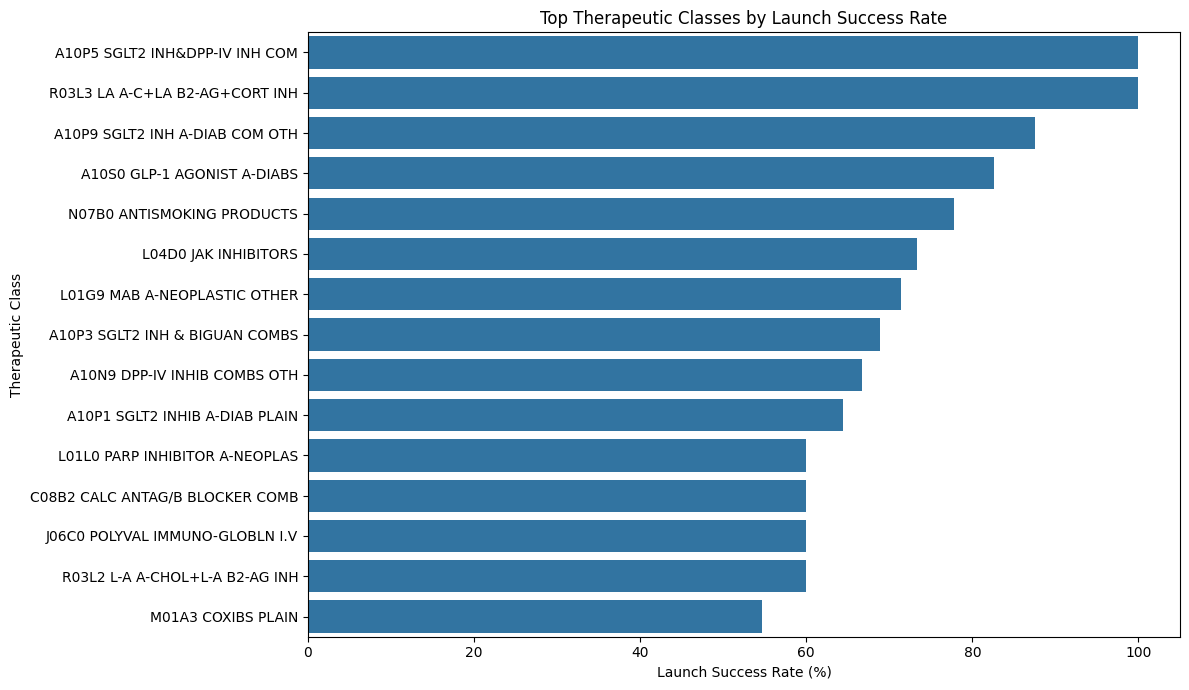

In [59]:
# ============================================================
# 43. TOP THERAPEUTIC CLASSES BY LAUNCH SUCCESS
# ============================================================

plot_data = (
    therapy_launch_success[
        therapy_launch_success["New_Products"] >= 5
    ]
    .sort_values(
        "Success_Rate_%",
        ascending=False
    )
    .head(15)
)

plt.figure(figsize=(12, 7))

sns.barplot(
    data=plot_data,
    x="Success_Rate_%",
    y="Therapeutic_Class"
)

plt.title(
    "Top Therapeutic Classes by Launch Success Rate"
)

plt.xlabel("Launch Success Rate (%)")
plt.ylabel("Therapeutic Class")

plt.tight_layout()
plt.show()

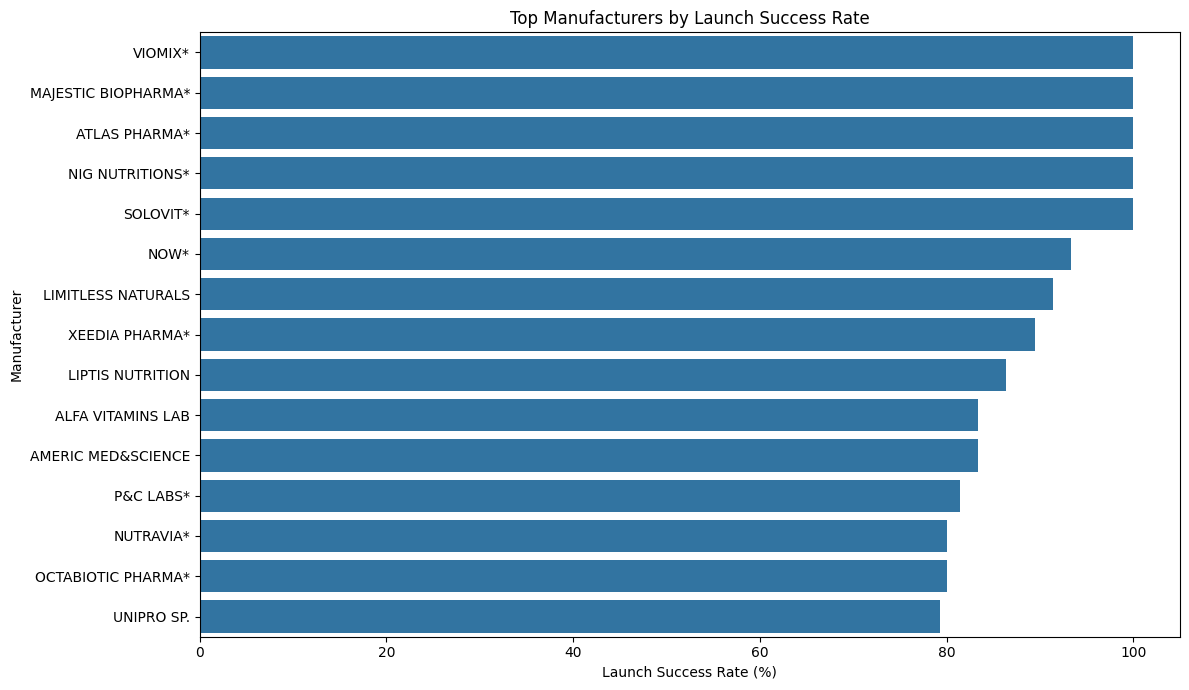

In [60]:
# ============================================================
# 44. TOP MANUFACTURERS BY LAUNCH SUCCESS
# ============================================================

plot_data = (
    manufacturer_reliable
    .sort_values(
        "Success_Rate_%",
        ascending=False
    )
    .head(15)
)

plt.figure(figsize=(12, 7))

sns.barplot(
    data=plot_data,
    x="Success_Rate_%",
    y="Manufacturer"
)

plt.title(
    "Top Manufacturers by Launch Success Rate"
)

plt.xlabel("Launch Success Rate (%)")
plt.ylabel("Manufacturer")

plt.tight_layout()
plt.show()

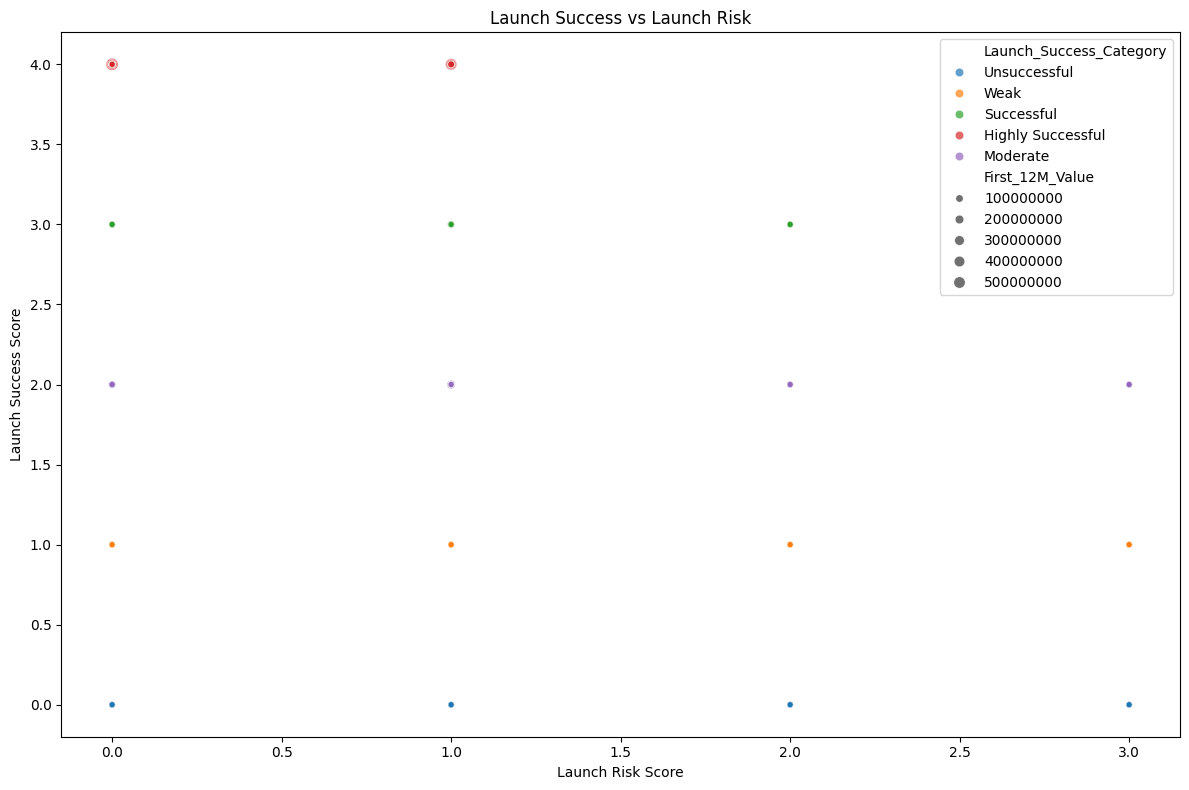

In [61]:
# ============================================================
# 45. LAUNCH SUCCESS VS RISK
# ============================================================

plt.figure(figsize=(12, 8))

sns.scatterplot(
    data=product_launch,
    x="Launch_Risk_Score",
    y="Launch_Success_Score",
    size="First_12M_Value",
    hue="Launch_Success_Category",
    alpha=0.7
)

plt.title(
    "Launch Success vs Launch Risk"
)

plt.xlabel("Launch Risk Score")
plt.ylabel("Launch Success Score")

plt.tight_layout()
plt.show()

In [62]:
# ============================================================
# 46. EXECUTIVE LAUNCH SUMMARY
# ============================================================

print("=" * 70)
print("PHARMALENS AI — EXECUTIVE LAUNCH SUMMARY")
print("=" * 70)

# ------------------------------------------------------------
# 1. Total launches
# ------------------------------------------------------------

total_launches = len(product_launch)

# ------------------------------------------------------------
# 2. Successful launches
# ------------------------------------------------------------

successful_launches = product_launch[
    product_launch["Launch_Success_Category"].isin(
        [
            "Highly Successful",
            "Successful"
        ]
    )
]

successful_count = len(successful_launches)

# ------------------------------------------------------------
# 3. Success rate
# ------------------------------------------------------------

launch_success_rate = (
    successful_count / total_launches * 100
    if total_launches > 0
    else 0
)

# ------------------------------------------------------------
# 4. High-risk launches
# ------------------------------------------------------------

high_risk_launches = product_launch[
    product_launch["Launch_Risk_Category"]
    == "High Risk"
]

high_risk_count = len(high_risk_launches)

high_risk_rate = (
    high_risk_count / total_launches * 100
    if total_launches > 0
    else 0
)

# ------------------------------------------------------------
# 5. Strategic opportunities
# ------------------------------------------------------------

scale_launches = product_launch[
    product_launch["Strategic_Launch_Segment"]
    == "Scale / Accelerate"
]

invest_launches = product_launch[
    product_launch["Strategic_Launch_Segment"]
    == "Invest / Expand"
]

optimize_launches = product_launch[
    product_launch["Strategic_Launch_Segment"]
    == "Optimize"
]

intervention_launches = product_launch[
    product_launch["Strategic_Launch_Segment"]
    == "Intervention Required"
]

# ------------------------------------------------------------
# 6. Executive metrics
# ------------------------------------------------------------

executive_summary = pd.DataFrame({
    "Metric": [
        "Total Launches",
        "Successful Launches",
        "Launch Success Rate (%)",
        "High Risk Launches",
        "High Risk Rate (%)",
        "Scale / Accelerate",
        "Invest / Expand",
        "Optimize",
        "Intervention Required"
    ],

    "Value": [
        total_launches,
        successful_count,
        launch_success_rate,
        high_risk_count,
        high_risk_rate,
        len(scale_launches),
        len(invest_launches),
        len(optimize_launches),
        len(intervention_launches)
    ]
})

# ------------------------------------------------------------
# 7. Display
# ------------------------------------------------------------

display(executive_summary)

print("\n" + "=" * 70)
print("EXECUTIVE INTERPRETATION")
print("=" * 70)

print(
    f"\nTotal launches analyzed: {total_launches:,}"
)

print(
    f"Successful launches: {successful_count:,}"
)

print(
    f"Launch success rate: {launch_success_rate:.2f}%"
)

print(
    f"High-risk launches: {high_risk_count:,} "
    f"({high_risk_rate:.2f}%)"
)

print(
    f"\nScale / Accelerate opportunities: "
    f"{len(scale_launches):,}"
)

print(
    f"Invest / Expand opportunities: "
    f"{len(invest_launches):,}"
)

print(
    f"Optimize opportunities: "
    f"{len(optimize_launches):,}"
)

print(
    f"Intervention Required: "
    f"{len(intervention_launches):,}"
)

PHARMALENS AI — EXECUTIVE LAUNCH SUMMARY


,Metric,Value
0,Total Launches,"16,500.00"
1,Successful Launches,"3,009.00"
2,Launch Success Rate (%),18.24
3,High Risk Launches,"1,228.00"
4,High Risk Rate (%),7.44
5,Scale / Accelerate,"2,409.00"
6,Invest / Expand,548.00
7,Optimize,204.00
8,Intervention Required,"1,198.00"



EXECUTIVE INTERPRETATION

Total launches analyzed: 16,500
Successful launches: 3,009
Launch success rate: 18.24%
High-risk launches: 1,228 (7.44%)

Scale / Accelerate opportunities: 2,409
Invest / Expand opportunities: 548
Optimize opportunities: 204
Intervention Required: 1,198


In [63]:
# ============================================================
# 47. EXECUTIVE LAUNCH KPIs
# ============================================================

launch_kpis = pd.DataFrame({
    "KPI": [
        "Total Products",
        "New Product Launches",
        "Launch Success Rate",
        "Highly Successful Launches",
        "Successful Launches",
        "Moderate Launches",
        "Weak / Unsuccessful Launches",
        "Average First 3M Value",
        "Average First 6M Value",
        "Average First 12M Value",
        "Median Time to Peak"
    ],

    "Value": [
        df["Product_ID"].nunique(),

        len(product_launch),

        success_rate,

        (
            product_launch[
                "Launch_Success_Category"
            ] == "Highly Successful"
        ).sum(),

        (
            product_launch[
                "Launch_Success_Category"
            ] == "Successful"
        ).sum(),

        (
            product_launch[
                "Launch_Success_Category"
            ] == "Moderate"
        ).sum(),

        (
            product_launch[
                "Launch_Success_Category"
            ].isin([
                "Weak",
                "Unsuccessful"
            ])
        ).sum(),

        product_launch[
            "First_3M_Value"
        ].mean(),

        product_launch[
            "First_6M_Value"
        ].mean(),

        product_launch[
            "First_12M_Value"
        ].mean(),

        product_launch[
            "Time_to_Peak_Months"
        ].median()
    ]
})

launch_kpis

,KPI,Value
0,Total Products,"16,682.00"
1,New Product Launches,"16,500.00"
2,Launch Success Rate,18.24
3,Highly Successful Launches,"2,409.00"
4,Successful Launches,600.00
5,Moderate Launches,507.00
6,Weak / Unsuccessful Launches,"12,984.00"
7,Average First 3M Value,"1,274,452.44"
8,Average First 6M Value,"2,847,897.60"
9,Average First 12M Value,"5,866,574.78"


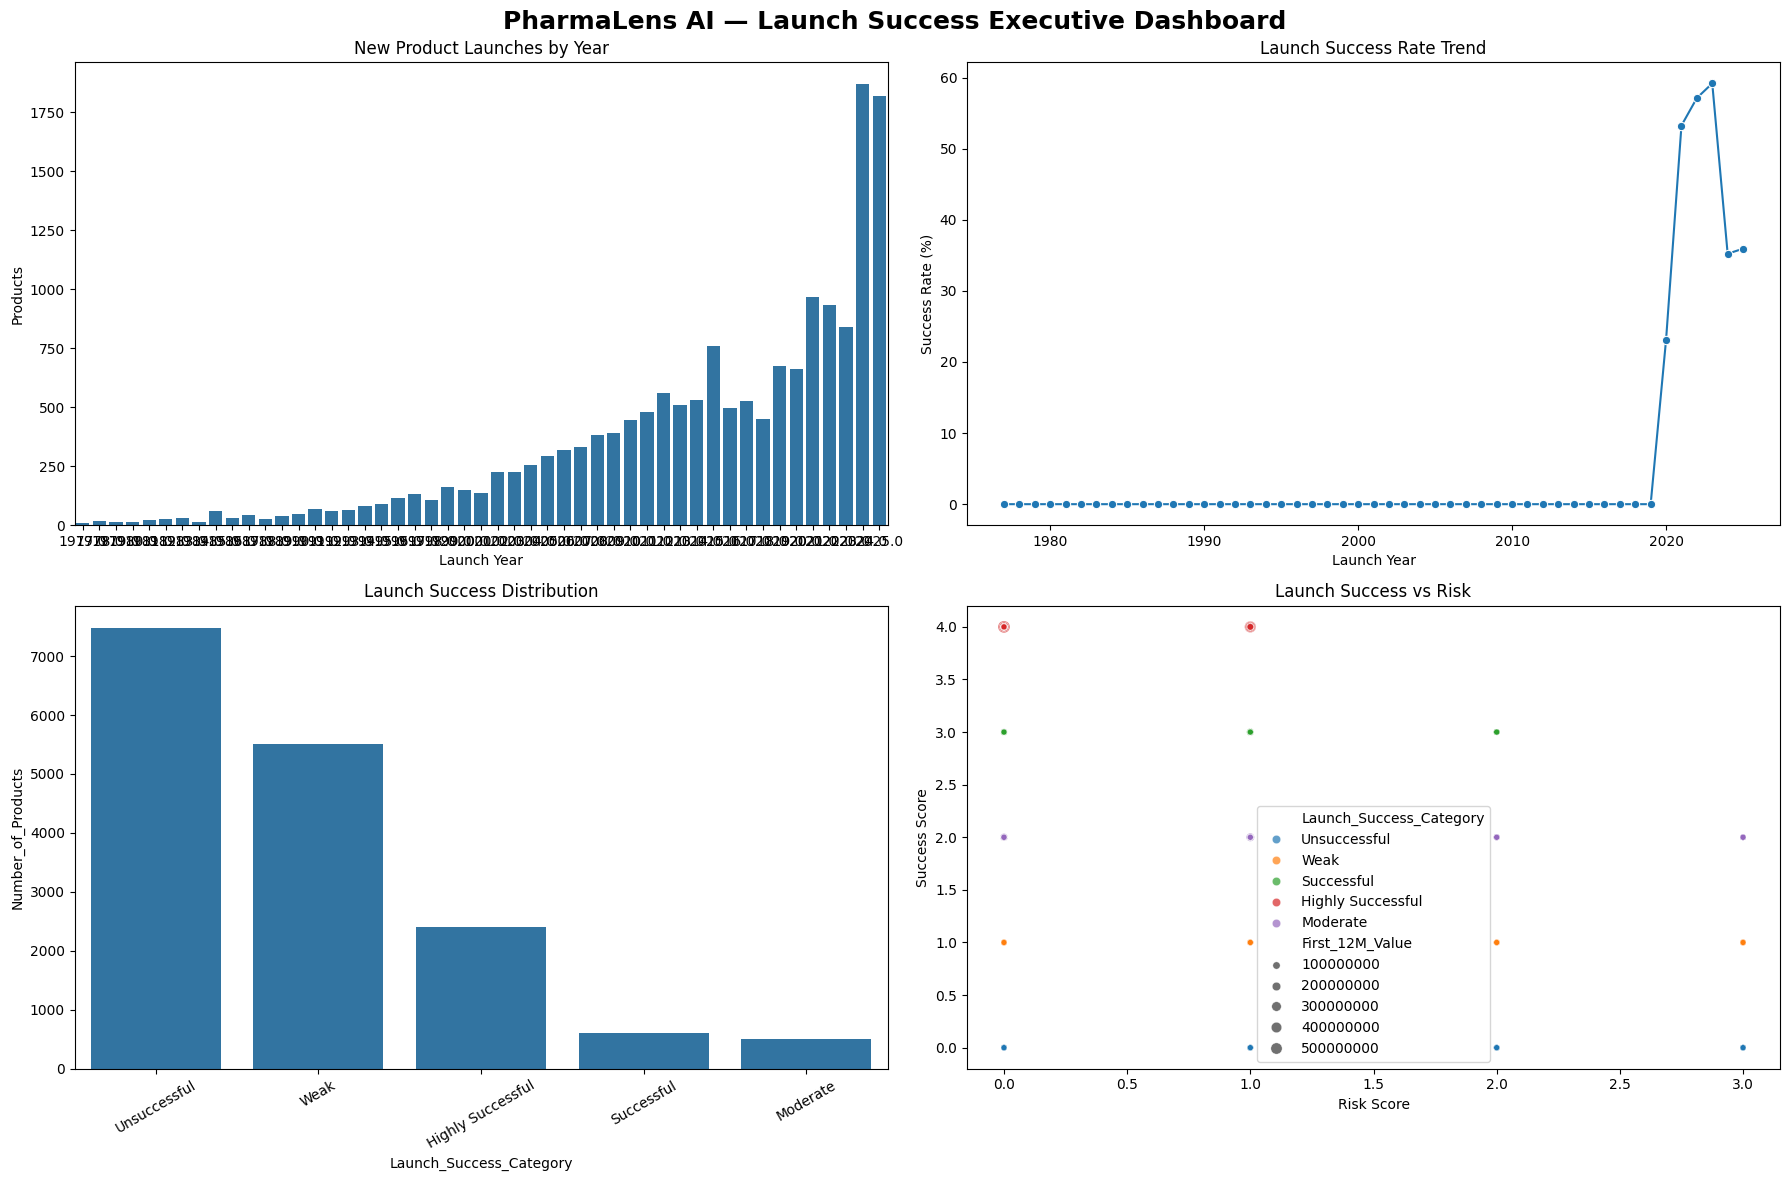

In [64]:
# ============================================================
# 48. EXECUTIVE LAUNCH DASHBOARD
# ============================================================

fig, axes = plt.subplots(
    2,
    2,
    figsize=(18, 12)
)

# ------------------------------------------------------------
# 1. Launches by Year
# ------------------------------------------------------------

sns.barplot(
    data=launch_cohort,
    x="Launch_Year",
    y="New_Products",
    ax=axes[0, 0]
)

axes[0, 0].set_title(
    "New Product Launches by Year"
)

axes[0, 0].set_xlabel("Launch Year")
axes[0, 0].set_ylabel("Products")

# ------------------------------------------------------------
# 2. Success Rate by Year
# ------------------------------------------------------------

sns.lineplot(
    data=success_by_year,
    x="Launch_Year",
    y="Success_Rate_%",
    marker="o",
    ax=axes[0, 1]
)

axes[0, 1].set_title(
    "Launch Success Rate Trend"
)

axes[0, 1].set_xlabel("Launch Year")
axes[0, 1].set_ylabel("Success Rate (%)")

# ------------------------------------------------------------
# 3. Success Categories
# ------------------------------------------------------------

sns.barplot(
    data=success_distribution,
    x="Launch_Success_Category",
    y="Number_of_Products",
    ax=axes[1, 0]
)

axes[1, 0].set_title(
    "Launch Success Distribution"
)

axes[1, 0].tick_params(
    axis="x",
    rotation=30
)

# ------------------------------------------------------------
# 4. Success vs Risk
# ------------------------------------------------------------

sns.scatterplot(
    data=product_launch,
    x="Launch_Risk_Score",
    y="Launch_Success_Score",
    size="First_12M_Value",
    hue="Launch_Success_Category",
    ax=axes[1, 1],
    alpha=0.7
)

axes[1, 1].set_title(
    "Launch Success vs Risk"
)

axes[1, 1].set_xlabel("Risk Score")
axes[1, 1].set_ylabel("Success Score")

plt.suptitle(
    "PharmaLens AI — Launch Success Executive Dashboard",
    fontsize=18,
    fontweight="bold"
)

plt.tight_layout()

plt.show()

In [65]:
# ============================================================
# 49. FINAL LAUNCH STRATEGY TABLE
# ============================================================

launch_strategy = (
    product_launch[
        [
            "Product_ID",
            "Manufacturer",
            "Brand_Name",
            "Therapeutic_Class",
            "Market_Category",
            "Launch_Year",
            "First_3M_Value",
            "First_6M_Value",
            "First_12M_Value",
            "Peak_Monthly_Value",
            "Time_to_Peak_Months",
            "Value_Growth_%",
            "Launch_Success_Score",
            "Launch_Success_Category",
            "Launch_Risk_Score",
            "Launch_Risk_Category",
            "Strategic_Launch_Segment"
        ]
    ]
    .sort_values(
        [
            "Launch_Success_Score",
            "First_12M_Value"
        ],
        ascending=False
    )
)

launch_strategy.head(100)

,Product_ID,Manufacturer,Brand_Name,Therapeutic_Class,Market_Category,Launch_Year,First_3M_Value,First_6M_Value,First_12M_Value,Peak_Monthly_Value,Time_to_Peak_Months,Value_Growth_%,Launch_Success_Score,Launch_Success_Category,Launch_Risk_Score,Launch_Risk_Category,Strategic_Launch_Segment
6317,HALEON* | PANADOL | 500MG | TABS ADVANCE 500MG 48,HALEON*,PANADOL,N02B0 NON-NARCOTIC ANALGESICS,AAA ORAL S ORD TABLETS,"2,023.00","124,906,316.00","268,880,856.00","564,494,554.00","118,005,824.00",12.00,169.83,4,Highly Successful,0,Minimal Risk,Scale / Accelerate
2557,BIOMED PHARMA.* | BIOLEGAM | 60MG | F.C.T.100M...,BIOMED PHARMA.*,BIOLEGAM,G04E1 ERECT DYS PRD PDE5 INHIB,ABC ORAL S ORD FILM-COATED TABS,"2,024.00","56,826,624.00","170,116,608.00","518,548,608.00","181,237,056.00",12.00,86.01,4,Highly Successful,0,Minimal Risk,Scale / Accelerate
4609,ELI LILLY* | MOUNJARO | 000 | KPP 15/0.6 2.4ML,ELI LILLY*,MOUNJARO,A10S0 GLP-1 AGONIST A-DIABS,FRF PARENT ORD P-FILLED PENS,"2,025.00","191,754,750.00","514,008,000.00","514,008,000.00","135,217,500.00",4.00,-96.65,4,Highly Successful,1,Low Risk,Scale / Accelerate
6308,HALEON* | PANADOL AC HEAD CO | 2MG | FCT 500/3...,HALEON*,PANADOL AC HEAD CO,R05A0 COLD PREPARATIONS,ABC ORAL S ORD FILM-COATED TABS,"2,024.00","70,295,199.00","155,773,605.00","454,387,427.00","96,466,978.00",9.00,-74.71,4,Highly Successful,1,Low Risk,Scale / Accelerate
2593,BIOMED PHARMA.* | GABIMASH | 800MG | TABS 800M...,BIOMED PHARMA.*,GABIMASH,N02D0 GABAPENTINOID PRODUCTS,AAA ORAL S ORD TABLETS,"2,022.00","35,111,959.44","141,292,269.87","398,226,075.87","267,912,144.00",32.00,727.49,4,Highly Successful,0,Minimal Risk,Scale / Accelerate
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3426,COPAD* | MEMEXA | 10MG | FILM C.TABS 10MG 30,COPAD*,MEMEXA,N07D9 ALL OTHER ANTI-ALZ PRODS,ABC ORAL S ORD FILM-COATED TABS,"2,023.00","9,082,755.00","32,447,286.00","76,527,672.00","23,165,328.00",25.00,"2,337.93",4,Highly Successful,0,Minimal Risk,Scale / Accelerate
5005,EVA PHARMA* | REMDESIVIR-EVA | 100MG | V.IV IN...,EVA PHARMA*,REMDESIVIR-EVA,J05B6 CORONAVIRUS ANTIVIRALS,FQC PARENT ORD INF VIALS/BOTTLES,"2,021.00","9,954,130.00","50,812,640.00","73,984,580.00","15,742,180.00",4.00,-49.73,4,Highly Successful,1,Low Risk,Scale / Accelerate
12458,PHARAONIA PH.* | OMEZ | 40MG | CAPS 40MG 20,PHARAONIA PH.*,OMEZ,A02B2 PROTON PUMP INHIBITORS,ACY ORAL S ORD OTHER CAPS,"2,022.00","4,719,286.00","36,259,788.66","73,939,821.05","27,045,460.00",39.00,"5,185.25",4,Highly Successful,0,Minimal Risk,Scale / Accelerate
8296,LIMITLESS NATURALS | CARNIVITA ADVANCE | 000 |...,LIMITLESS NATURALS,CARNIVITA ADVANCE,G04X0 ALL OTH UROLOGICAL PRODS,DEP ORAL L ORD UNIT DOSE POWDERS,"2,021.00","9,512,800.00","28,360,840.00","73,885,047.75","17,597,250.00",30.00,8.17,4,Highly Successful,0,Minimal Risk,Scale / Accelerate


In [66]:
# ============================================================
# 50. EXPORT LAUNCH INTELLIGENCE RESULTS
# ============================================================

output_file = "../data/Launch_Success_Intelligence.xlsx"

with pd.ExcelWriter(
    output_file,
    engine="openpyxl"
) as writer:

    product_launch.to_excel(
        writer,
        sheet_name="Product Launch",
        index=False
    )

    launch_cohort.to_excel(
        writer,
        sheet_name="Launch Cohort",
        index=False
    )

    success_by_year.to_excel(
        writer,
        sheet_name="Success by Year",
        index=False
    )

    manufacturer_launch_success.to_excel(
        writer,
        sheet_name="Manufacturer Success",
        index=False
    )

    therapy_launch_success.to_excel(
        writer,
        sheet_name="Therapy Success",
        index=False
    )

    category_launch_success.to_excel(
        writer,
        sheet_name="Category Success",
        index=False
    )

    strategic_launch_opportunities.to_excel(
        writer,
        sheet_name="Strategic Opportunities",
        index=False
    )

    launch_kpis.to_excel(
        writer,
        sheet_name="Executive KPIs",
        index=False
    )

    launch_strategy.to_excel(
        writer,
        sheet_name="Launch Strategy",
        index=False
    )

print(
    f"Launch intelligence exported to: {output_file}"
)

Launch intelligence exported to: ../data/Launch_Success_Intelligence.xlsx


In [67]:
# ============================================================
# 51. FINAL EXECUTIVE CONCLUSIONS
# ============================================================

total_launches = len(product_launch)

successful_count = (
    product_launch[
        "Launch_Success_Category"
    ].isin([
        "Successful",
        "Highly Successful"
    ])
).sum()

high_risk_count = (
    product_launch[
        "Launch_Risk_Category"
    ] == "High Risk"
).sum()

top_manufacturer = (
    manufacturer_reliable
    .sort_values(
        "Success_Rate_%",
        ascending=False
    )
    .iloc[0]
    if len(manufacturer_reliable) > 0
    else None
)

top_therapy = (
    therapy_launch_success[
        therapy_launch_success["New_Products"] >= 5
    ]
    .sort_values(
        "Success_Rate_%",
        ascending=False
    )
    .iloc[0]
    if len(
        therapy_launch_success[
            therapy_launch_success["New_Products"] >= 5
        ]
    ) > 0
    else None
)

print("=" * 70)
print("PHARMALENS AI — LAUNCH SUCCESS EXECUTIVE CONCLUSIONS")
print("=" * 70)

print(
    f"\n1. Total identified product launches: "
    f"{total_launches:,}"
)

print(
    f"2. Successful launches: "
    f"{successful_count:,}"
)

print(
    f"3. Overall launch success rate: "
    f"{success_rate:.2f}%"
)

print(
    f"4. High-risk launches: "
    f"{high_risk_count:,}"
)

print(
    f"5. Average first 12-month launch value: "
    f"{product_launch['First_12M_Value'].mean():,.2f}"
)

print(
    f"6. Median time-to-peak: "
    f"{product_launch['Time_to_Peak_Months'].median():.1f} months"
)

if top_manufacturer is not None:
    print(
        f"7. Best manufacturer launch success rate "
        f"(minimum 5 launches): "
        f"{top_manufacturer['Manufacturer']} "
        f"({top_manufacturer['Success_Rate_%']:.2f}%)"
    )

if top_therapy is not None:
    print(
        f"8. Best therapeutic-class launch success rate "
        f"(minimum 5 launches): "
        f"{top_therapy['Therapeutic_Class']} "
        f"({top_therapy['Success_Rate_%']:.2f}%)"
    )

print("\n" + "=" * 70)
print("Strategic interpretation:")
print("=" * 70)

print("""
• Successful launches should be prioritized for acceleration and
  additional commercial investment.

• Products with strong early sales but high launch risk should be
  monitored closely and supported through targeted interventions.

• Weak early launches require rapid diagnosis of pricing, channel,
  market access, competitive pressure and commercial execution.

• Therapeutic classes with consistently high launch success represent
  attractive areas for future portfolio expansion.

• Manufacturers with repeatable launch success can be benchmarked
  against weaker launch performers.

• Time-to-peak provides an important indicator of launch velocity and
  commercial execution.

• The launch intelligence output can be connected to the GTM,
  recommendation and forecasting notebooks in later stages.
""")

PHARMALENS AI — LAUNCH SUCCESS EXECUTIVE CONCLUSIONS

1. Total identified product launches: 16,500
2. Successful launches: 3,009
3. Overall launch success rate: 18.24%
4. High-risk launches: 1,228
5. Average first 12-month launch value: 5,866,574.78
6. Median time-to-peak: 65.0 months
7. Best manufacturer launch success rate (minimum 5 launches): VIOMIX* (100.00%)
8. Best therapeutic-class launch success rate (minimum 5 launches): A10P5 SGLT2 INH&DPP-IV INH COM (100.00%)

Strategic interpretation:

• Successful launches should be prioritized for acceleration and
  additional commercial investment.

• Products with strong early sales but high launch risk should be
  monitored closely and supported through targeted interventions.

• Weak early launches require rapid diagnosis of pricing, channel,
  market access, competitive pressure and commercial execution.

• Therapeutic classes with consistently high launch success represent
  attractive areas for future portfolio expansion.

• Manuf